# 0. Importación de librerias

In [17]:
# !pip install statsmodels
# !pip install stable-baselines3
# !pip install sb3-contrib


In [18]:
# Librerías para el análisis de datos
import numpy as np  # Biblioteca para operaciones numéricas, especialmente útil para trabajar con matrices y arrays
import pandas as pd  # Biblioteca para manipulación y análisis de datos, especialmente para DataFrames
import statsmodels.api as sm  # Biblioteca para realizar modelos estadísticos, útil para regresiones y otros análisis estadísticos
from collections import Counter  # Contador de elementos en colecciones, útil para contar la frecuencia de elementos en una lista o array

# Librería para optimización
from gurobipy import Model, GRB, quicksum  # Gurobi es una biblioteca de optimización matemática. 
# Model permite definir el modelo de optimización,
# GRB contiene constantes (como tipos de variables y sentido de optimización),
# quicksum permite realizar sumas de forma rápida y eficiente en Gurobi.

# Librerías operacionales
import os  # Biblioteca para interactuar con el sistema operativo (ej. manejo de archivos y rutas)
from datetime import datetime  # Módulo para trabajar con fechas y tiempos, útil para capturar fechas actuales o manipular datos de tiempo
import matplotlib.pyplot as plt

# rl
# # Importar las librerías necesarias
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor
import gc
import logging  
from sklearn.preprocessing import normalize
from joblib import Parallel, delayed 
import warnings

import requests

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# <h2>1. Carga de datos desde excel a dataframes de pandas</h2>


In [19]:
def verificar_y_descargar(url, filename):
    """
    Verifica si el archivo existe localmente. Si no, lo descarga desde la URL proporcionada.
    """
    if not os.path.exists(filename):
        print(f"Descargando {filename} desde {url} ...")
        response = requests.get(url)
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Archivo {filename} descargado exitosamente.")
    else:
        print(f"El archivo {filename} ya existe localmente.")

En primer lugar se cargan los datos iniciales desde los csv que nos proveen. (Esto puede tardar un ratito)

## <h3>1.1 Carga de 'Informacion_Clientes.csv'</h3>

En primer lugar se cargará la información de los clientes. Esto incluye las siguientes características de los clientes:

* **unnamed**: algo como uid
* **Rut**: identificador de Chile (supongo que por privacidad va desde 0 a max de observaciones)
* **Género**: Masculino o femenino
* **Categoría_Digital**: Si el cliente es digital o no
* **Elasticidad_Precios**: Baja, media o alta
* **Nacionalidad**: Chileno o extranjero
* **Propensión**: Número entre 0 y 1 que idica que tan propenso a cursar un credito es el cliente
* **Probabilidad_No_Pago**: Número entre 0 y 1 que indica la probabilidad de que el cliente no pague la deuda
* **Edad**: Numero entero de edad en años
* **Renta**: Renta promedio de los últimos 12 meses
* **Oferta_Consumo**: Monto máximo que puede cursar un cliente dado sus antecedentes crediticios y situación socioeconómica. 
* **Deuda_CMF**: Deuda que tiene el cliente en otros bancos. Efectivamente es deuda pendiente, pero de créditos otorgados por la competencia.
* **Tiempo_como_cliente**: Número de tiempo(no sé en que medida está) que el cliente lleva en el banco


In [20]:
file_id = '173bRZQG7NWfdpHJ-o4-NA3ieH1-Fhyok'
url_informacion_de_clientes = f'https://drive.google.com/uc?id={file_id}'
filename = "Informacion_Clientes.csv"

verificar_y_descargar(url_informacion_de_clientes, filename)
df_informacion_de_clientes = pd.read_csv(filename)

El archivo Informacion_Clientes.csv ya existe localmente.


Se elimina el tiempo como cliente ya que no aporta información

In [21]:
df_informacion_de_clientes.drop(columns=['Tiempo_como_cliente'], inplace=True)

## <h3>1.2 Carga de 'Simulaciones_Clientes.csv'</h3>



En segundo lugar se cargaran las simulaciones hechas por los clientes en la página del banco. Esto incluye las siguientes características de las simulaciones:
* **unnamed**: Supongo que es el número de simulacion registrada, un tipo de identificador de la simulación
* **fecha**: yyyy-mm-dd fecha de la simulación
* **rut**: identificador de Chile del cliente que hizo la simulacion
* **monto_simulado**: monto prestado al cliente
* **plazo_simulado**: plazo en **meses** del crédito
* **tasa_simulado**: costo para el cliente del credito

In [22]:
url_simulaciones_clientes = 'https://drive.usercontent.google.com/download?id=1IXyKwtKFLCUsAV1MtNqktiwKaHzV2D5A&authuser=0&confirm=t&uuid=edd22376-238f-4c1f-b603-728b07bafd7f&at=AENtkXaEURpV52p_BdWxyisvjhSQ%3A1730951026384'
filename = "Simulaciones_clientes.csv"
verificar_y_descargar(url_simulaciones_clientes, filename)

df_simulaciones_clientes = pd.read_csv(filename)

El archivo Simulaciones_clientes.csv ya existe localmente.


In [23]:
df_simulaciones_clientes = df_simulaciones_clientes[df_simulaciones_clientes['Monto_Simulado'] > 0]

## <h3>1.3 Carga de 'Tratamiento.csv'</h3>

En tercer lugar se cargara el tratamiento que ha tenido el banco con el cliente, es decir, cómo se han contactado con él. Esto incluye las siguientes características:

* **unnamed**: Número de tratamiento registrado
* **fecha**: yyyy-mm-dd
* **rut**: Identificador de Chile del cliente con el que se tiene el tipo de trato
* **n_correos**: Cantidad de correos que se enviaron en el mes que sale la fecha. Es decir, si sele fecha '2024-03-01', correspondería a los correos enviados en marzo de 2024.
* **asg_ejec**: Si el cliente tiene un ejecutivo asignado

In [24]:
url_tratamiento = 'https://drive.usercontent.google.com/download?id=1KTRwYGaWoQQnZwbk8VpdxKULMaOReoF5&authuser=0&confirm=t&uuid=4e4d7983-c5a5-412d-9f5b-b9bda1068b73&at=AENtkXZSxkDr84kWrDlz6ANq4ov2%3A1730951312566'
filename = "Tratamiento.csv"

verificar_y_descargar(url_tratamiento, filename)
df_tratamiento = pd.read_csv(filename)

El archivo Tratamiento.csv ya existe localmente.


## <h3>1.4 Carga de 'Ventas.csv'</h3>

Por último se cargaran las ventas que ha tenido el banco con el cliente. Esto incluye las siguientes características:

* **unnamed**: Índice sin significado
* **fecha**: yyyy-mm-dd -> fecha en la que se concretó la venta
* **rut**: identificador de Chile del cliente al que se le concretó la venta

In [25]:
file_id = '1Z4jMzZeD2q-4-ioSgyimppAdLZzqDkt3'
url_ventas = f'https://drive.google.com/uc?id={file_id}'
filename = "Ventas.csv"

verificar_y_descargar(url_ventas, filename)
df_ventas = pd.read_csv(filename)

Descargando Ventas.csv desde https://drive.google.com/uc?id=1Z4jMzZeD2q-4-ioSgyimppAdLZzqDkt3 ...
Archivo Ventas.csv descargado exitosamente.


## <h3>1.5 Filtrar data (fECHA) para que corra en el compu - omitir en la ejecucion final</h3>

In [26]:
Filtrar_data = True

Fecha_inicio = '2022-01-01'

if Filtrar_data:
    # df_simulaciones_clientes
    df_simulaciones_clientes['fecha'] = pd.to_datetime(df_simulaciones_clientes['fecha'])
    df_simulaciones_clientes = df_simulaciones_clientes[df_simulaciones_clientes['fecha'] >= Fecha_inicio]
    # df_tratamiento
    df_tratamiento['fecha'] = pd.to_datetime(df_tratamiento['fecha'])
    df_tratamiento = df_tratamiento[df_tratamiento['fecha'] >= Fecha_inicio]
    # df_ventas
    df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
    df_ventas = df_ventas[df_ventas['fecha'] >= Fecha_inicio]


# <h2>2. Joints de datos<h2>

In [27]:
# Unir los DataFrames 'df_informacion_de_clientes' y 'df_simulaciones_clientes' en base a la columna 'rut'
# El método 'how="left"' asegura que todos los registros de 'df_informacion_de_clientes' se conserven,
# incluso si no tienen coincidencia en 'df_simulaciones_clientes'.
df_simulaciones_e_informacion_de_clientes = pd.merge(
    df_informacion_de_clientes, 
    df_simulaciones_clientes, 
    on='rut', 
    how='left'
)

# Crear una nueva columna 'simulo' que indica si el cliente tiene un 'Monto_Simulado' o no
# El método 'notna()' devuelve True para valores no nulos y False para nulos.
# Luego, 'astype(int)' convierte estos valores booleanos en enteros (1 para True, 0 para False).
df_simulaciones_e_informacion_de_clientes['simulo'] = df_simulaciones_e_informacion_de_clientes['Monto_Simulado'].notna().astype(int)

# Eliminar columnas innecesarias 'Unnamed: 0_x' y 'Unnamed: 0_y' que podrían haber surgido durante la carga o manipulación de datos
df_simulaciones_e_informacion_de_clientes.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'], inplace=True)


In [28]:
df_simulaciones_e_informacion_de_clientes

,rut,Genero,Categoria_Digital,Elasticidad_Precios,Nacionalidad,Propension,Probabilidad_No_Pago,Edad,Renta,Oferta_Consumo,Deuda_CMF,fecha,Monto_Simulado,Plazo_Simulado,Tasa_Simulado,simulo
0,1,Masculino,Cliente no Digital,Alta,Chileno,0.997340,0.028445,30.0,625818.326221,2164276.0,712585.357842,2022-03-01,262380.0,31.0,1.687877,1
1,1,Masculino,Cliente no Digital,Alta,Chileno,0.997340,0.028445,30.0,625818.326221,2164276.0,712585.357842,2022-08-01,249106.0,34.0,2.343216,1
2,1,Masculino,Cliente no Digital,Alta,Chileno,0.997340,0.028445,30.0,625818.326221,2164276.0,712585.357842,2022-10-01,265687.0,34.0,1.849433,1
3,1,Masculino,Cliente no Digital,Alta,Chileno,0.997340,0.028445,30.0,625818.326221,2164276.0,712585.357842,2023-04-01,236814.0,32.0,2.358720,1
4,1,Masculino,Cliente no Digital,Alta,Chileno,0.997340,0.028445,30.0,625818.326221,2164276.0,712585.357842,2023-05-01,298669.0,27.0,1.383783,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3872873,543651,Femenino,Cliente no Digital,Media,Chileno,0.860781,0.019647,35.0,472806.728024,1979540.0,574575.649505,2023-03-01,403331.0,17.0,2.356028,1
3872874,543651,Femenino,Cliente no Digital,Media,Chileno,0.860781,0.019647,35.0,472806.728024,1979540.0,574575.649505,2023-08-01,359897.0,16.0,2.478376,1
3872875,543651,Femenino,Cliente no Digital,Media,Chileno,0.860781,0.019647,35.0,472806.728024,1979540.0,574575.649505,2024-03-01,348048.0,18.0,2.301079,1
3872876,543651,Femenino,Cliente no Digital,Media,Chileno,0.860781,0.019647,35.0,472806.728024,1979540.0,574575.649505,2024-05-01,344504.0,16.0,2.462272,1


In [29]:
# Unir los DataFrames 'df_simulaciones_e_informacion_de_clientes' y 'df_ventas' en base a las columnas 'rut' y 'fecha'
# El método 'how="left"' asegura que todos los registros de 'df_simulaciones_e_informacion_de_clientes' se conserven,
# incluso si no tienen coincidencia en 'df_ventas'.
df_simulaciones_e_informacion_de_clientes_ventas = pd.merge( 
    df_simulaciones_e_informacion_de_clientes, 
    df_ventas, 
    on=['rut', 'fecha'], 
    how='left'
)

# Crear una nueva columna 'venta' que indica si existe una venta asociada al cliente y la fecha específica
# El método 'notna()' verifica si hay un valor no nulo en la columna 'Unnamed: 0' (que indica presencia de una venta)
# Luego, 'astype(int)' convierte estos valores booleanos en enteros (1 para True, 0 para False).
df_simulaciones_e_informacion_de_clientes_ventas['venta'] = df_simulaciones_e_informacion_de_clientes_ventas['Unnamed: 0'].notna().astype(int)


In [30]:
# Unir los DataFrames 'df_simulaciones_e_informacion_de_clientes_ventas' y 'df_tratamiento' en base a las columnas 'rut' y 'fecha'
# La unión se realiza con 'how="left"' para conservar todos los registros de 'df_simulaciones_e_informacion_de_clientes_ventas'
# incluso si no tienen coincidencia en 'df_tratamiento'.
df_simulaciones_e_informacion_de_clientes_ventas_tratamiento = pd.merge( 
    df_simulaciones_e_informacion_de_clientes_ventas, 
    df_tratamiento, 
    on=['rut', 'fecha'], 
    how='left'
)

# Crear una nueva columna 'mes' que extrae el mes y año de la columna 'fecha'
# Primero se convierte 'fecha' al formato datetime, luego 'dt.to_period('M')' obtiene el periodo del mes/año.
df_simulaciones_e_informacion_de_clientes_ventas_tratamiento['mes'] = pd.to_datetime(df_simulaciones_e_informacion_de_clientes_ventas_tratamiento['fecha']).dt.to_period('M')

# Eliminar las columnas 'Unnamed: 0_x' y 'Unnamed: 0_y' ya que no aportan información relevante
df_simulaciones_e_informacion_de_clientes_ventas_tratamiento.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'], inplace=True)

# 3. CLUSTERING POR POLITICAS

### Seteo de cluster. Aquí se definen las variables y sus cortes. La idea es que el algoritmo de RL haga sus acciones en esta sección

Aquí se definen que variables se utilizarán para crear el cluster

In [31]:
df_informacion_de_clientes_procesados_cluster_definitivo = df_informacion_de_clientes[['rut', 'Elasticidad_Precios', 'Edad', 'Genero', 'Renta', 'Probabilidad_No_Pago']].copy()


Aqui se definen en que partes y en cuantas partes se particionarán las variables escogidas anteriormente

In [32]:
# Crear una copia del DataFrame 'df_informacion_de_clientes_procesados_cluster_definitivo' para trabajar sin modificar el original
df = df_informacion_de_clientes_procesados_cluster_definitivo.copy()

# Clasificar la columna 'Probabilidad_No_Pago' en cinco categorías, asignando etiquetas según los valores de probabilidad
# Cada categoría representa el nivel de confiabilidad en el pago: desde 'Muy buen pagador' hasta 'Muy mal pagador'.
df['Categoria_Probabilidad_No_Pago'] = pd.cut(df['Probabilidad_No_Pago'], 
                                              bins=[-float('inf'), 0.0085402934056559, float('inf')],
                                              labels=['Buen pagador', 'Mal pagador'])

# Clasificar la columna 'Edad' en tres categorías: 'Joven', 'Adulto' y 'Adulto Mayor'
# Cada categoría se define en función de rangos de edad especificados en 'bins'.
df['Categoria_Edad'] = pd.cut(df['Edad'], 
                              bins=[-float('inf'), 31, float('inf')],
                              labels=['Joven', 'Adulto'])

# Crear un DataFrame único de 'rut' y 'Renta' eliminando duplicados, para calcular percentiles de renta
df_unicos_renta = df[['rut', 'Renta']].drop_duplicates()

# Clasificar la columna 'Percentil_Renta' en tres categorías: 'Renta Baja', 'Renta Media' y 'Renta Alta'
# Los rangos de percentil especificados en 'bins' definen estas categorías.
df_unicos_renta['Categoria_Renta'] = pd.cut(df_unicos_renta['Renta'], 
                                            bins=[-float('inf'), 705468.9044051456, 1382978.7928061879, float('inf')],
                                            labels=['Renta Baja', 'Renta Media', 'Renta Alta'])

# Incorporar la categoría de renta al DataFrame principal 'df' realizando una unión ('merge') en base a la columna 'rut'
df = df.merge(df_unicos_renta[['rut', 'Categoria_Renta']], on='rut', how='left')

# Mostrar el DataFrame resultante con las nuevas columnas creadas
df


,rut,Elasticidad_Precios,Edad,Genero,Renta,Probabilidad_No_Pago,Categoria_Probabilidad_No_Pago,Categoria_Edad,Categoria_Renta
0,1,Alta,30.0,Masculino,6.258183e+05,0.028445,Mal pagador,Joven,Renta Baja
1,2,Baja,41.0,Femenino,3.172616e+05,0.014320,Mal pagador,Adulto,Renta Baja
2,3,Baja,38.0,Femenino,1.240551e+07,0.002156,Buen pagador,Adulto,Renta Alta
3,4,Alta,57.0,Masculino,5.441466e+05,0.034418,Mal pagador,Adulto,Renta Baja
4,5,Media,26.0,Masculino,1.870225e+05,0.014978,Mal pagador,Joven,Renta Baja
...,...,...,...,...,...,...,...,...,...
543646,543647,Baja,29.0,Femenino,1.176598e+05,0.037291,Mal pagador,Joven,Renta Baja
543647,543648,Baja,31.0,Masculino,1.558612e+06,0.035877,Mal pagador,Joven,Renta Alta
543648,543649,Media,49.0,Masculino,9.449508e+05,0.023306,Mal pagador,Adulto,Renta Media
543649,543650,Media,40.0,Femenino,1.039964e+06,0.015121,Mal pagador,Adulto,Renta Media


In [33]:
# Concatenar las variables especificadas en una nueva columna 'categoria_clusterizacion'
# La columna resultante combinará varias categorías en una descripción detallada del perfil del cliente.
# Convertimos cada columna a tipo string para asegurarnos de que los datos sean compatibles para la concatenación.

df['categoria_clusterizacion'] = (
    df['Elasticidad_Precios'].astype(str) + ' ' +              # Categoría de digitalización del cliente
    df['Categoria_Edad'].astype(str) + ' de genero ' +       # Categoría de edad, seguida de la palabra "de genero"
    df['Genero'].astype(str) + ' con una ' +                     # Género del cliente
    df['Categoria_Renta'].astype(str) + 'que es un ' +                      # Categoría de renta
    df['Categoria_Probabilidad_No_Pago'].astype(str)  # Categoría de probabilidad de no pago
)


In [34]:
# Asignar un número único a cada entrada distinta en la columna 'categoria_clusterizacion'
# Se convierte la columna a tipo 'category', lo cual facilita la asignación de códigos numéricos únicos.
# 'cat.codes' asigna un código numérico único para cada valor único de 'categoria_clusterizacion'.
df['categoria_clusterizacion_numerica'] = df['categoria_clusterizacion'].astype('category').cat.codes


In [35]:
# Crear una copia del DataFrame con solo las columnas 'rut', 'categoria_clusterizacion' y 'categoria_clusterizacion_numerica'
# Esta copia se almacena en el nuevo DataFrame 'asignacion_clusters', el cual contendrá únicamente la identificación del cliente (rut),
# la descripción del perfil ('categoria_clusterizacion') y el código numérico asignado a cada perfil ('categoria_clusterizacion_numerica').
asignacion_clusters = df[['rut', 'categoria_clusterizacion', 'categoria_clusterizacion_numerica']].copy()


# 4. Estimacion de curvas de elasticidad por cluster

In [36]:
# Realizar una unión entre 'df_simulaciones_e_informacion_de_clientes_ventas' y 'asignacion_clusters' usando la columna 'rut' como clave
# Esta unión ('merge') se realiza con 'how="left"', lo que asegura que todos los registros de 'df_simulaciones_e_informacion_de_clientes_ventas' 
# se conserven, incluyendo aquellos sin coincidencia en 'asignacion_clusters'.
# La finalidad es agregar la información de clusterización (categoría y código numérico) al DataFrame de simulaciones y ventas.
df_estimar_elasticidad = pd.merge(df_simulaciones_e_informacion_de_clientes_ventas, asignacion_clusters, on='rut', how='left')


In [37]:
def plot_elasticity_curve_with_histogram(tasas_grid, acceptance_probability, tasa_optima, df_cluster, cluster_num, output_folder):
    """
    Grafica la curva de elasticidad con la tasa óptima marcada y un histograma
    que muestra ventas y no ventas para cada precio, con mejoras en la visualización.
    
    Args:
    - tasas_grid (numpy array): Valores de la tasa simulada (eje X).
    - acceptance_probability (numpy array): Probabilidades de aceptación (eje Y).
    - tasa_optima (float): Tasa óptima encontrada.
    - df_cluster (DataFrame): Datos del cluster actual, incluyendo 'Tasa_Simulado' y 'venta'.
    - cluster_num (int): Número del cluster para el título.
    - output_folder (str): Ruta de la carpeta donde se guardará el gráfico.
    """
    # Preparar datos para el histograma
    ventas = df_cluster[df_cluster['venta'] == 1]['Tasa_Simulado']
    no_ventas = df_cluster[df_cluster['venta'] == 0]['Tasa_Simulado']
    
    # Crear la figura
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Curva de elasticidad
    ax1.plot(tasas_grid, acceptance_probability, label="Curva de Elasticidad", color='blue', linewidth=2)
    ax1.axvline(x=tasa_optima, color='green', linestyle='--', label=f"Tasa Óptima: {tasa_optima:.2f}%", zorder=10)
    ax1.set_xlabel("Tasa Simulada (%)", fontsize=12)
    ax1.set_ylabel("Probabilidad de Aceptación", fontsize=12, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_ylim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.2, 1))  # Leyenda fuera de la gráfica
    
    # Histograma de ventas y no ventas (usar el segundo eje Y)
    ax2 = ax1.twinx()
    ax2.hist([ventas, no_ventas], bins=20, color=['blue', 'red'], alpha=0.3, label=["Ventas", "No Ventas"], stacked=True)
    ax2.set_ylabel("Frecuencia de Ventas", fontsize=12, color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.legend(loc='upper left', bbox_to_anchor=(1.2, 0.85))  # Leyenda fuera de la gráfica

    # Título
    plt.title(f"Curva de Elasticidad y Ventas por Tasa - Cluster {cluster_num}", fontsize=14)
    
    # Ajustar diseño para evitar superposiciones
    plt.tight_layout()
    
    # Guardar el gráfico
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    output_path = os.path.join(output_folder, f"curva_elasticidad_cluster_{cluster_num}.png")
    plt.savefig(output_path)
    print(f"Gráfico guardado en: {output_path}")
    plt.close()


### Este código realiza un análisis de elasticidad de ingresos en función de clusters de clientes. Primero, agrupa los datos por clusters definidos a través de variables de segmentación y filtra solo los datos relevantes para cada cluster. Luego, para cada cluster, se ajusta un modelo de regresión logística para predecir la probabilidad de aceptación de una simulación de crédito en función de la tasa de interés. A partir de este modelo, se crea una cuadrícula de tasas para estimar la probabilidad de aceptación y calcular el revenue potencial de cada simulación, teniendo en cuenta el monto medio simulado, el plazo medio simulado y la probabilidad media de no pago del cluster. Posteriormente, se determina la tasa que maximiza el revenue esperado y se calcula el número esperado de créditos aceptados, junto con el número de clientes únicos en cada cluster. Finalmente, los resultados se agregan tanto en listas globales como en un nuevo DataFrame, y luego se integran en el DataFrame original df_estimar_elasticidad, lo que permite analizar el revenue esperado total y otros indicadores clave en cada cluster.

In [38]:
def function_estimar_elasticidad(df_estimar_elasticidad):
    # Inicializar listas para almacenar resultados globales de revenue, clientes, créditos y simulaciones
    lista_revenue = []
    lista_clientes = []
    lista_creditos = []
    lista_simulaciones = []

    cluster_results = []  # Lista para almacenar resultados específicos de cada cluster

    # Obtener los números únicos de cada cluster
    cluster_numbers = df_estimar_elasticidad['categoria_clusterizacion_numerica'].unique()

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_folder = f"hg_reglog_{timestamp}"
    os.makedirs(output_folder, exist_ok=True)

    # Iterar sobre cada cluster identificado por 'categoria_clusterizacion_numerica'
    for cluster_num in cluster_numbers:
        # Filtrar los datos correspondientes al cluster actual
        df_cluster = df_estimar_elasticidad[df_estimar_elasticidad['categoria_clusterizacion_numerica'] == cluster_num]
        
        # Asegurarse de que existen datos para ambos casos: venta == 1 y venta == 0
        if df_cluster.empty or df_cluster['venta'].isnull().all():
            continue  # Saltar este cluster si no cumple con la condición
        
        # Remover filas donde 'venta' o 'Tasa_Simulado' son nulos o infinitos
        df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan)
        df_cluster = df_cluster.dropna(subset=['venta', 'Tasa_Simulado', 'Plazo_Simulado', 'Monto_Simulado', 'Probabilidad_No_Pago'])
        
        # Saltar el cluster si no hay suficientes puntos de datos
        if df_cluster.shape[0] < 10:
            continue
        
        # Extraer las variables 'venta' (como variable dependiente) y 'Tasa_Simulado' (como predictor)
        y = df_cluster['venta']
        X = df_cluster[['Tasa_Simulado']]
        
        # Añadir un término constante para el intercepto
        X = sm.add_constant(X)
        
        # Remover filas con valores NaN o Inf en X o y
        is_finite = np.isfinite(X).all(1) & np.isfinite(y)
        X = X[is_finite]
        y = y[is_finite]
        
        # Asegurarse de que después de remover NaN/Inf, todavía hay suficientes datos
        if len(y) < 10:
            continue
        
        # Ajustar el modelo de regresión logística
        logit_model = sm.Logit(y, X)
        try:
            result = logit_model.fit(disp=0)
        except:
            continue  # Saltar el cluster si el modelo no converge
        
        # Crear una cuadrícula de valores de 'Tasa_Simulado' para predicciones
        tasa_min = df_cluster['Tasa_Simulado'].min()
        tasa_max = df_cluster['Tasa_Simulado'].max()
        tasas_grid = np.linspace(tasa_min, tasa_max, 1000)
        
        # Predecir la probabilidad de aceptación usando el modelo ajustado
        X_grid = sm.add_constant(tasas_grid)
        acceptance_probability = result.predict(X_grid)
        
        # Asegurar que las probabilidades están en el rango [0, 1]
        acceptance_probability = np.clip(acceptance_probability, 0, 1)

        # Calcular valores medios necesarios para el cálculo de revenue
        n = df_cluster['Plazo_Simulado'].mean()
        vp = df_cluster['Monto_Simulado'].mean()
        pnp = df_cluster['Probabilidad_No_Pago'].mean()
        data = {
            'Plazo_Simulado_medio': n, 
            'Monto_Simulado_medio': vp, 
            'Probabilidad_No_Pago_media': pnp
        }
        
        # Calcular el revenue potencial
        i = tasas_grid / 100  # Convertir a decimal
        one_plus_i_pow_n = np.power(1 + i, n)
        annuity_factor = (i * one_plus_i_pow_n) / (one_plus_i_pow_n - 1)
        revenue = (n * vp * annuity_factor) - vp
        potential_revenue = revenue * (1 - pnp)
        
        # Calcular el promedio de simulaciones por fecha
        df_cluster_simulaciones_1 = df_cluster[df_cluster['simulo'] == 1]
        num_dates = df_cluster_simulaciones_1['fecha'].nunique()
        total_simulaciones = df_cluster_simulaciones_1['simulo'].sum()
        simulaciones_medias = total_simulaciones / num_dates if num_dates else 0
        
        # Saltar el cluster si no hay simulaciones
        if simulaciones_medias == 0:
            continue
        
        # Calcular el revenue esperado
        expected_revenue = acceptance_probability * potential_revenue * simulaciones_medias
        
        # Encontrar la tasa que maximiza el revenue esperado
        idx_max = np.argmax(expected_revenue)
        max_price = tasas_grid[idx_max]
        max_expected_revenue = expected_revenue[idx_max]
        
        # Probabilidad de aceptación en la tasa óptima
        prob_aceptacion_optima = acceptance_probability[idx_max]
        
        # Llamar a la función para graficar la curva y el histograma
        # plot_elasticity_curve_with_histogram(
        #     tasas_grid, 
        #     acceptance_probability, 
        #     max_price, 
        #     df_cluster,  # Pasamos todo el DataFrame del cluster actual
        #     cluster_num, 
        #     output_folder
        # )

        # Número esperado de créditos aceptados
        num_creditos_aceptados = round(prob_aceptacion_optima * simulaciones_medias)
        
        # Número de clientes únicos en el cluster
        num_clients = df_cluster['rut'].nunique()
        
        # Imprimir resultados para cada cluster
        print(f'Cluster {cluster_num}:')
        print(f'- Precio Máx. Revenue Esperado = {max_price:.2f}%')
        print(f'- Revenue Esperado Máximo = {max_expected_revenue:,.2f}')
        print(f'- Número de clientes en el cluster = {num_clients}')
        print(f'- Número de simulaciones en el cluster = {simulaciones_medias:.2f}')
        print(f'- Probabilidad de aceptación en el precio óptimo = {prob_aceptacion_optima:.4f}')
        print(f'- Número esperado de créditos aceptados = {num_creditos_aceptados}')
        print(f'- Monto medio simulado = {data["Monto_Simulado_medio"]:,.2f}')
        print(f'- Plazo medio simulado = {data["Plazo_Simulado_medio"]:,.2f}')
        print(f'- Probabilidad de no pago media = {data["Probabilidad_No_Pago_media"]:.4f}\n')

        # Agregar resultados a las listas globales
        lista_clientes.append(num_clients)
        lista_revenue.append(max_expected_revenue)
        lista_creditos.append(num_creditos_aceptados)
        lista_simulaciones.append(simulaciones_medias)
        
        # Almacenar resultados por cluster en cluster_results
        cluster_results.append({
            'categoria_clusterizacion_numerica': cluster_num,
            'tasa_optima': max_price,
            'probabilidad_aceptacion_optima': prob_aceptacion_optima,
            'revenue_esperado_maximo': max_expected_revenue,
            'numero_clientes': num_clients,
            'numero_simulaciones_medias': simulaciones_medias,
            'numero_creditos_esperados': num_creditos_aceptados,
            'monto_medio_simulado': data["Monto_Simulado_medio"],
            'plazo_medio_simulado': data["Plazo_Simulado_medio"],
            'probabilidad_no_pago_media': data["Probabilidad_No_Pago_media"]
        })

    # Imprimir resultados globales
    total_revenue = sum(lista_revenue)
    total_clientes = sum(lista_clientes)
    total_simulaciones = sum(lista_simulaciones)
    total_creditos = sum(lista_creditos)

    print(f"El revenue total esperado es: {total_revenue:,.2f} con un total de {total_clientes} clientes, "
        f"{total_simulaciones:,.2f} simulaciones, y {total_creditos} créditos.")

    # Crear un DataFrame a partir de cluster_results
    df_cluster_results = pd.DataFrame(cluster_results)

    # Incorporar los resultados por cluster de 'df_cluster_results' a 'df_estimar_elasticidad'
    df_estimar_elasticidad = df_estimar_elasticidad.merge(
        df_cluster_results[['categoria_clusterizacion_numerica', 'tasa_optima', 'probabilidad_aceptacion_optima']],
        on='categoria_clusterizacion_numerica', 
        how='left'
    )
    return {'df_estimar_elasticidad': df_estimar_elasticidad, 'total_revenue': total_revenue, 'total_clientes': total_clientes, 'total_simulaciones': total_simulaciones, 'total_creditos': total_creditos}


In [39]:
df_estimar_elasticidad = function_estimar_elasticidad(df_estimar_elasticidad)['df_estimar_elasticidad']

Cluster 21:
- Precio Máx. Revenue Esperado = 2.50%
- Revenue Esperado Máximo = 42,101,168.77
- Número de clientes en el cluster = 7045
- Número de simulaciones en el cluster = 1668.03
- Probabilidad de aceptación en el precio óptimo = 0.4030
- Número esperado de créditos aceptados = 672
- Monto medio simulado = 164,685.14
- Plazo medio simulado = 27.48
- Probabilidad de no pago media = 0.0358

Cluster 27:
- Precio Máx. Revenue Esperado = 1.00%
- Revenue Esperado Máximo = 303,898,589.36
- Número de clientes en el cluster = 11600
- Número de simulaciones en el cluster = 2698.80
- Probabilidad de aceptación en el precio óptimo = 0.7386
- Número esperado de créditos aceptados = 1993
- Monto medio simulado = 1,037,582.12
- Plazo medio simulado = 27.60
- Probabilidad de no pago media = 0.0159

Cluster 24:
- Precio Máx. Revenue Esperado = 1.00%
- Revenue Esperado Máximo = 16,857,112,802.71
- Número de clientes en el cluster = 29033
- Número de simulaciones en el cluster = 7467.47
- Probabilid

# 5. Estimacion de respuesta a tratamiento por cluster

In [40]:
# Unir los DataFrames 'df_tratamiento' y 'df_simulaciones_clientes' usando las columnas 'rut' y 'fecha' como claves
# La unión se realiza con 'how="left"', lo cual asegura que todos los registros de 'df_tratamiento' se conserven,
# incluyendo aquellos sin coincidencia en 'df_simulaciones_clientes'.
# Esta operación permite combinar la información de tratamiento con los datos de simulaciones de clientes.
df_simulaciones_info = pd.merge(df_tratamiento, df_simulaciones_clientes, on=['rut', 'fecha'], how='left')


In [41]:
# Tamaño del chunk (ajusta según la RAM, 1 millón es seguro)
chunk_size = 1_000_000

# DataFrame resultante
result_chunks = []

# Procesar por bloques
for start in range(0, len(df_simulaciones_info), chunk_size):
    end = start + chunk_size
    print(f"Procesando filas {start} a {end}...")

    # Crear un bloque de datos
    chunk = df_simulaciones_info.iloc[start:end].copy()

    # Asegurarse de que no haya NaN y convertir tipos
    chunk['asg_ejec'] = chunk['asg_ejec'].fillna('Desconocido').astype(str)
    chunk['n_correos'] = pd.to_numeric(chunk['n_correos'], errors='coerce').fillna(0).astype(int)

    # Crear la columna Tratamiento
    chunk['Tratamiento'] = (
        'Ejecutivo=' + chunk['asg_ejec'] +
        ', Correos=' + chunk['n_correos'].astype(str)
    )

    # Guardar el chunk procesado
    result_chunks.append(chunk)

# Combinar todos los chunks en un solo DataFrame
df_simulaciones_info = pd.concat(result_chunks, ignore_index=True)


Procesando filas 0 a 1000000...
Procesando filas 1000000 a 2000000...
Procesando filas 2000000 a 3000000...
Procesando filas 3000000 a 4000000...
Procesando filas 4000000 a 5000000...
Procesando filas 5000000 a 6000000...
Procesando filas 6000000 a 7000000...
Procesando filas 7000000 a 8000000...
Procesando filas 8000000 a 9000000...
Procesando filas 9000000 a 10000000...
Procesando filas 10000000 a 11000000...
Procesando filas 11000000 a 12000000...
Procesando filas 12000000 a 13000000...
Procesando filas 13000000 a 14000000...
Procesando filas 14000000 a 15000000...
Procesando filas 15000000 a 16000000...
Procesando filas 16000000 a 17000000...


In [42]:
# Extraer el mes y año de la columna 'fecha' y crear una nueva columna 'mes' en formato de periodo mensual
# Se convierte 'fecha' al formato datetime y luego se usa 'dt.to_period('M')' para obtener el mes/año.
df_simulaciones_info['mes'] = pd.to_datetime(df_simulaciones_info['fecha']).dt.to_period('M')

# Filtrar y mostrar las filas donde 'rut' es igual a 1
# Este filtro permite observar los registros específicos del cliente con 'rut' igual a 1, 
# lo cual es útil para verificar datos o analizar un cliente en particular.
df_simulaciones_info[df_simulaciones_info['rut'] == 1]


,Unnamed: 0_x,fecha,rut,n_correos,asg_ejec,Unnamed: 0_y,Monto_Simulado,Plazo_Simulado,Tasa_Simulado,Tratamiento,mes
0,0,2022-01-01,1,3,0,NaN,NaN,NaN,NaN,"Ejecutivo=0, Correos=3",2022-01
543651,0,2022-02-01,1,2,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=2",2022-02
1087302,0,2022-03-01,1,1,0,7864778.0,262380.0,31.0,1.687877,"Ejecutivo=0, Correos=1",2022-03
1630953,0,2022-04-01,1,2,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=2",2022-04
2174604,0,2022-05-01,1,0,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=0",2022-05
2718255,0,2022-06-01,1,4,0,NaN,NaN,NaN,NaN,"Ejecutivo=0, Correos=4",2022-06
3261906,0,2022-07-01,1,0,0,NaN,NaN,NaN,NaN,"Ejecutivo=0, Correos=0",2022-07
3805557,0,2022-08-01,1,4,0,7864779.0,249106.0,34.0,2.343216,"Ejecutivo=0, Correos=4",2022-08
4349208,0,2022-09-01,1,0,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=0",2022-09
4892859,0,2022-10-01,1,1,1,7864780.0,265687.0,34.0,1.849433,"Ejecutivo=1, Correos=1",2022-10


In [43]:
# Crear una nueva columna 'simulo' para indicar si el cliente tiene un registro de simulación
# La columna 'Unnamed: 0_y' se utiliza para verificar si hay un valor no nulo, lo que implica que hay una simulación.
# 'notna()' devuelve True para valores no nulos y False para valores nulos; luego, 'astype(int)' convierte estos valores a 1 (True) o 0 (False).
df_simulaciones_info['simulo'] = df_simulaciones_info['Unnamed: 0_y'].notna().astype(int)

# Filtrar y mostrar las filas donde 'rut' es igual a 1
# Este filtro permite observar los registros específicos del cliente con 'rut' igual a 1, 
# útil para verificar si la columna 'simulo' refleja correctamente la presencia de simulaciones para este cliente.
df_simulaciones_info[df_simulaciones_info['rut'] == 1]


,Unnamed: 0_x,fecha,rut,n_correos,asg_ejec,Unnamed: 0_y,Monto_Simulado,Plazo_Simulado,Tasa_Simulado,Tratamiento,mes,simulo
0,0,2022-01-01,1,3,0,NaN,NaN,NaN,NaN,"Ejecutivo=0, Correos=3",2022-01,0
543651,0,2022-02-01,1,2,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=2",2022-02,0
1087302,0,2022-03-01,1,1,0,7864778.0,262380.0,31.0,1.687877,"Ejecutivo=0, Correos=1",2022-03,1
1630953,0,2022-04-01,1,2,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=2",2022-04,0
2174604,0,2022-05-01,1,0,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=0",2022-05,0
2718255,0,2022-06-01,1,4,0,NaN,NaN,NaN,NaN,"Ejecutivo=0, Correos=4",2022-06,0
3261906,0,2022-07-01,1,0,0,NaN,NaN,NaN,NaN,"Ejecutivo=0, Correos=0",2022-07,0
3805557,0,2022-08-01,1,4,0,7864779.0,249106.0,34.0,2.343216,"Ejecutivo=0, Correos=4",2022-08,1
4349208,0,2022-09-01,1,0,1,NaN,NaN,NaN,NaN,"Ejecutivo=1, Correos=0",2022-09,0
4892859,0,2022-10-01,1,1,1,7864780.0,265687.0,34.0,1.849433,"Ejecutivo=1, Correos=1",2022-10,1


In [44]:
# Crear una copia del DataFrame 'df_estimar_elasticidad' con solo las columnas especificadas
# 'df1' contiene las columnas 'rut', 'categoria_clusterizacion_numerica', 'tasa_optima' y 'probabilidad_aceptacion_optima'.
# Esta copia es útil para trabajar con los datos de elasticidad y clusterización sin modificar el DataFrame original.
df1 = df_estimar_elasticidad[['rut', 'categoria_clusterizacion_numerica', 'tasa_optima', 'probabilidad_aceptacion_optima']].copy()

# Crear una copia del DataFrame 'df_simulaciones_info' con solo las columnas especificadas
# 'df2' contiene las columnas 'rut', 'mes', 'Tratamiento' y 'simulo'.
# Esta copia es útil para trabajar con los datos de tratamiento y simulación en un conjunto de datos reducido.
df2 = df_simulaciones_info[['rut', 'mes', 'Tratamiento', 'simulo']].copy()


In [45]:
def function_estimar_respuesta_a_tratamiento(df_estimar_elasticidad, df_simulaciones_info): #df1 es df_estimar_elasticidad y df2 es df_simulaciones_info
    df_estimar_elasticidad_unique = df_estimar_elasticidad.drop_duplicates(subset='rut')

    # Convertir categorías antes de mapear
    df_estimar_elasticidad_unique['categoria_clusterizacion_numerica'] = df_estimar_elasticidad_unique['categoria_clusterizacion_numerica'].astype('int32')
    df_simulaciones_info['rut'] = df_simulaciones_info['rut'].astype('int64')  # asumido
    df_simulaciones_info['Tratamiento'] = df_simulaciones_info['Tratamiento'].astype('category')

    rut_cluster_map = df_estimar_elasticidad_unique.set_index('rut')['categoria_clusterizacion_numerica']
    df_simulaciones_info['categoria_clusterizacion_numerica'] = df_simulaciones_info['rut'].map(rut_cluster_map)

    # Eliminar filas con NaN
    df_simulaciones_info.dropna(subset=['categoria_clusterizacion_numerica'], inplace=True)
    df_simulaciones_info['categoria_clusterizacion_numerica'] = df_simulaciones_info['categoria_clusterizacion_numerica'].astype('int32')

    # Optimizar tipos de datos
    df_simulaciones_info['simulo'] = pd.to_numeric(df_simulaciones_info['simulo'], errors='coerce').fillna(0).astype('int8')

    # Convertir 'Tratamiento' a tipo de categoría para optimizar espacio y realizar operaciones categóricas.
    df_simulaciones_info['Tratamiento'] = df_simulaciones_info['Tratamiento'].astype('category')

    # Paso 2: Calcular el caso total (entradas por tratamiento sin importar el valor de 'simulo')
    # Agrupar por 'categoria_clusterizacion_numerica' y 'Tratamiento' para contar el número total de registros en cada combinación.
    total_entries_per_cluster_treatment = df_simulaciones_info.groupby(['categoria_clusterizacion_numerica', 'Tratamiento']).size().reset_index(name='caso_total')

    # Paso 3: Calcular el caso favorable (entradas por tratamiento cuando 'simulo' == 1)
    # Filtrar filas donde 'simulo' es 1 (clientes que realizaron una simulación)
    df_simulations = df_simulaciones_info[df_simulaciones_info['simulo'] == 1]

    # Agrupar por 'categoria_clusterizacion_numerica' y 'Tratamiento' para contar el número de registros favorables (simulaciones).
    favorable_entries_per_cluster_treatment = df_simulations.groupby(['categoria_clusterizacion_numerica', 'Tratamiento']).size().reset_index(name='caso_favorable')

    # Paso 4: Calcular la probabilidad de simulación como caso favorable / caso total
    # Realizar un merge entre 'total_entries_per_cluster_treatment' y 'favorable_entries_per_cluster_treatment' en las columnas de cluster y tratamiento.
    df_probabilities = total_entries_per_cluster_treatment.merge(
        favorable_entries_per_cluster_treatment,
        on=['categoria_clusterizacion_numerica', 'Tratamiento'],
        how='left'
    )

    # Llenar valores nulos en 'caso_favorable' con 0, asegurando que solo las columnas numéricas estén afectadas.
    df_probabilities['caso_favorable'] = df_probabilities['caso_favorable'].fillna(0).astype(int)

    # Asegurar que 'caso_total' sea de tipo entero para evitar inconsistencias en los conteos.
    df_probabilities['caso_total'] = df_probabilities['caso_total'].astype(int)

    # Calcular la probabilidad de simulación como el cociente entre 'caso_favorable' y 'caso_total'.
    df_probabilities['probabilidad_simular'] = df_probabilities['caso_favorable'] / df_probabilities['caso_total']

    # Organizar las columnas del DataFrame resultante para facilitar su análisis.
    df_probabilities = df_probabilities[[
        'categoria_clusterizacion_numerica',
        'Tratamiento',
        'probabilidad_simular',
        'caso_favorable',
        'caso_total'
    ]]

    # Mostrar el DataFrame resultante con la probabilidad de simulación calculada para cada combinación de cluster y tratamiento.
    return df_probabilities


In [46]:
df_probabilities = function_estimar_respuesta_a_tratamiento(df1, df2)
df_probabilities

C:\Users\jimmy\AppData\Local\Temp\ipykernel_1680\3637930882.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_estimar_elasticidad_unique['categoria_clusterizacion_numerica'] = df_estimar_elasticidad_unique['categoria_clusterizacion_numerica'].astype('int32')


,categoria_clusterizacion_numerica,Tratamiento,probabilidad_simular,caso_favorable,caso_total
0,0,"Ejecutivo=0, Correos=0",0.145751,1504,10319
1,0,"Ejecutivo=0, Correos=1",0.155749,1738,11159
2,0,"Ejecutivo=0, Correos=2",0.160106,1391,8688
3,0,"Ejecutivo=0, Correos=3",0.170184,3677,21606
4,0,"Ejecutivo=0, Correos=4",0.174822,6024,34458
...,...,...,...,...,...
571,71,"Ejecutivo=0, Correos=3",0.173841,3259,18747
572,71,"Ejecutivo=0, Correos=4",0.178072,5251,29488
573,71,"Ejecutivo=1, Correos=0",0.337284,1309,3881
574,71,"Ejecutivo=1, Correos=1",0.342061,1437,4201


In [47]:
# Visualizar el DataFrame 'df_estimar_elasticidad' para revisar su contenido antes de realizar cálculos adicionales
df_estimar_elasticidad

# Calcular el valor promedio de 'Monto_Simulado' para cada 'categoria_clusterizacion_numerica'
# Usamos 'groupby' para agrupar por 'categoria_clusterizacion_numerica' y 'transform("mean")' para calcular el promedio.
# Luego, 'transform' asigna este valor promedio a cada fila dentro de su grupo, creando una columna 'Monto_Simulado_mean' con estos promedios.
df_estimar_elasticidad['Monto_Simulado_mean'] = df_estimar_elasticidad.groupby('categoria_clusterizacion_numerica')['Monto_Simulado'].transform('mean')

# Calcular el valor promedio de 'Plazo_Simulado' para cada 'categoria_clusterizacion_numerica'
# Similar al cálculo anterior, 'groupby' agrupa los datos por 'categoria_clusterizacion_numerica', y 'transform("mean")' calcula el promedio.
# Se asigna el promedio resultante a cada fila dentro del grupo en la nueva columna 'Plazo_Simulado_mean'.
df_estimar_elasticidad['Plazo_Simulado_mean'] = df_estimar_elasticidad.groupby('categoria_clusterizacion_numerica')['Plazo_Simulado'].transform('mean')
df_estimar_elasticidad['Plazo_Simulado_min'] = df_estimar_elasticidad.groupby('categoria_clusterizacion_numerica')['Plazo_Simulado'].transform('min')
df_estimar_elasticidad['Plazo_Simulado_max'] = df_estimar_elasticidad.groupby('categoria_clusterizacion_numerica')['Plazo_Simulado'].transform('max')
df_estimar_elasticidad['Plazo_Simulado_mode'] = df_estimar_elasticidad.groupby('categoria_clusterizacion_numerica')['Plazo_Simulado'].transform(lambda x: x.mode().iloc[0])


In [48]:
# Seleccionar solo las columnas necesarias del DataFrame 'df_estimar_elasticidad' para reducir su tamaño
# 'df_estimar_elasticidad_small' contiene las columnas esenciales para el análisis:
# 'categoria_clusterizacion_numerica', 'rut', 'tasa_optima', 'probabilidad_aceptacion_optima', 'Probabilidad_No_Pago',
# 'Monto_Simulado_mean', y 'Plazo_Simulado_mean'.
df_estimar_elasticidad_small = df_estimar_elasticidad[['categoria_clusterizacion_numerica', 'rut', 'tasa_optima', 'probabilidad_aceptacion_optima', 'Probabilidad_No_Pago', 
                                                       'Monto_Simulado_mean',
                                                       'Plazo_Simulado_mean', 'Plazo_Simulado_min', 'Plazo_Simulado_max', 'Plazo_Simulado_mode']]

# Seleccionar solo las columnas necesarias del DataFrame 'df_probabilities' para reducir su tamaño
# 'df_probabilities_small' contiene las columnas 'categoria_clusterizacion_numerica', 'probabilidad_simular', y 'Tratamiento'.
df_probabilities_small = df_probabilities[['categoria_clusterizacion_numerica', 'probabilidad_simular', 'Tratamiento']]

# Realizar un merge entre 'df_estimar_elasticidad_small' y 'df_probabilities_small' usando 'categoria_clusterizacion_numerica' como clave
# Esta unión ('how="left"') mantiene todas las filas de 'df_estimar_elasticidad_small' y añade la información de 'df_probabilities_small'
# cuando hay coincidencias en 'categoria_clusterizacion_numerica'. El resultado se guarda en 'df_asignacion_de_tratamientos'.

# Asegúrate de que ambas columnas sean del mismo tipo (por ejemplo, int)
df_estimar_elasticidad_small['categoria_clusterizacion_numerica'] = df_estimar_elasticidad_small['categoria_clusterizacion_numerica'].astype(int)
df_probabilities_small['categoria_clusterizacion_numerica'] = df_probabilities_small['categoria_clusterizacion_numerica'].astype(int)

# Ahora realiza el merge
df_asignacion_de_tratamientos = pd.merge(
    df_estimar_elasticidad_small,
    df_probabilities_small,
    on='categoria_clusterizacion_numerica',
    how='left'
)

C:\Users\jimmy\AppData\Local\Temp\ipykernel_1680\2602544680.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_estimar_elasticidad_small['categoria_clusterizacion_numerica'] = df_estimar_elasticidad_small['categoria_clusterizacion_numerica'].astype(int)
C:\Users\jimmy\AppData\Local\Temp\ipykernel_1680\2602544680.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_probabilities_small['categoria_clusterizacion_numerica'] = df_probabilities_small['categoria_clusterizacion_numerica'].astype(int)


In [49]:
# Crear un nombre de carpeta con una marca de tiempo actual
# 'strftime' genera la fecha y hora actual en el formato "YYYYMMDD_HHMMSS".
# Esto se usa para crear una carpeta única 'folder_name' donde se guardarán los archivos.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
folder_name = f"cluster_data_{timestamp}"
os.makedirs(folder_name, exist_ok=True)  # Crear la carpeta; 'exist_ok=True' evita errores si ya existe.

# Guardar información de los clusters
# Seleccionar las columnas relevantes sobre cada cluster desde 'df_estimar_elasticidad_small' y eliminar duplicados.
# El DataFrame 'df_cluster_info' contiene datos únicos de cada cluster como el monto y plazo medio simulado, la probabilidad de aceptación óptima y la tasa óptima.
df_cluster_info = df_estimar_elasticidad_small[['categoria_clusterizacion_numerica', 'probabilidad_aceptacion_optima', 'tasa_optima',
                                                'Monto_Simulado_mean',
                                                'Plazo_Simulado_mean', 'Plazo_Simulado_min', 'Plazo_Simulado_max', 'Plazo_Simulado_mode']].drop_duplicates()
df_cluster_info.to_csv(f"{folder_name}/cluster_info.csv", index=False)

# Guardar las probabilidades y tratamiento
# Seleccionar columnas relevantes de 'df_probabilities_small' para almacenar la probabilidad de simulación y tratamiento asignado para cada cluster.
# 'df_probabilities_treatment' contiene esta información única por cada combinación de cluster y tratamiento.
df_probabilities_treatment = df_probabilities_small[['categoria_clusterizacion_numerica', 'probabilidad_simular', 'Tratamiento']].drop_duplicates()
df_probabilities_treatment.to_csv(f"{folder_name}/probabilities_treatment.csv", index=False)

# Guardar información del RUT
# Seleccionar columnas clave sobre cada cliente ('rut') desde 'df_estimar_elasticidad_small' y eliminar duplicados.
# 'df_rut_info' contiene el 'rut', la categoría de cluster y la probabilidad de no pago para cada cliente, sin registros duplicados.
df_rut_info = df_estimar_elasticidad_small[['rut', 'categoria_clusterizacion_numerica', 'Probabilidad_No_Pago']].drop_duplicates()
df_rut_info.to_csv(f"{folder_name}/rut_info.csv", index=False)


# 6. Modelo de asignacion

## Modelo de asignacion que itera por cluster

In [50]:
def modelo_optimizacion(df_probabilities_treatment, df_rut_info, df_cluster_info, costo_sms, ejecutivos):
    # -------------------------------
    # Procesamiento y preprocesamiento de datos
    # -------------------------------

    # Definir la carpeta base y el mapeo de tratamientos
    tratamiento_map = {  # Mapeo de los tratamientos específicos a identificadores numéricos
        "Ejecutivo=0, Correos=0": 1, "Ejecutivo=0, Correos=1": 2,
        "Ejecutivo=0, Correos=2": 3, "Ejecutivo=0, Correos=3": 4,
        "Ejecutivo=0, Correos=4": 5, "Ejecutivo=1, Correos=0": 6,
        "Ejecutivo=1, Correos=1": 7, "Ejecutivo=1, Correos=2": 8
    }

    # Parámetros
    costosms = costo_sms # Costo de cada mensaje SMS
    capacidad_ejecutivos = ejecutivos  # Capacidad máxima en términos de tiempo de los ejecutivos

    # Paso 1: Cargar y mapear 'tratamiento_id' en los datos de probabilidades
    print("Loading and processing probabilities data...")
    df_probabilities = df_probabilities_treatment
    df_probabilities['tratamiento_id'] = df_probabilities['Tratamiento'].map(tratamiento_map)

    # Paso 2: Crear lista de tratamientos y combinar con rut_info
    print("Merging probabilities with rut_info...")
    df_probabilities['tratamientos'] = df_probabilities[['probabilidad_simular', 'tratamiento_id']].values.tolist()
    grouped_prob = df_probabilities.groupby('categoria_clusterizacion_numerica')['tratamientos'].apply(list).reset_index()


    df_rut_info1 = df_rut_info.merge(grouped_prob, on='categoria_clusterizacion_numerica', how='left')


    # Paso 3: Combinar rut_info con cluster_info
    print("Merging rut_info with cluster_info...")
    df_cluster_info = df_cluster_info
    df_rut_info2 = df_rut_info1.merge(df_cluster_info, on='categoria_clusterizacion_numerica', how='left')

    # Paso 3.5: Agrupar información por cluster en 'rut_info'
    # Agrupar por 'categoria_clusterizacion_numerica' y agregar según lo especificado
    df_grouped = df_rut_info2.groupby('categoria_clusterizacion_numerica').agg({
        'Probabilidad_No_Pago': 'mean',  # Promedio de probabilidad de no pago
        'tratamientos': lambda x: list(x),  # Lista de opciones de tratamiento únicas en cada cluster
        'Monto_Simulado_mean': 'mean',
        'Plazo_Simulado_mean': 'mean',
        'probabilidad_aceptacion_optima': 'mean',
        'tasa_optima': 'mean',
        'rut': 'count'  # Conteo del número de clientes ('rut') en cada cluster
    }).rename(columns={'rut': 'n_clientes'}).reset_index()

    # Paso 4: Calcular 'RC' (Revenue calculado)
    print("Calculating RC...")
    df_grouped['tasa_optima'] /= 100  # Convertir tasa óptima a decimal
    df_grouped['RC'] = (
        (df_grouped['Plazo_Simulado_mean'] * df_grouped['Monto_Simulado_mean'] * df_grouped['tasa_optima'] *
        ((1 + df_grouped['tasa_optima']) ** df_grouped['Plazo_Simulado_mean'])) /
        (((1 + df_grouped['tasa_optima']) ** df_grouped['Plazo_Simulado_mean']) - 1)
    ) - df_grouped['Monto_Simulado_mean']

    # -------------------------------
    # Preparación de datos para optimización
    # -------------------------------

    # Convertir 'tratamientos' a un arreglo de numpy para mejorar la indexación
    # Desarrollar y preparar 'tratamientos' para indexación adecuada
    profits = np.array([
        [
            row['n_clientes'] * (row['RC'] * (1 - row['Probabilidad_No_Pago']) * row['probabilidad_aceptacion_optima'] * row['tratamientos'][int(t)][0] ) - 
            (row['tratamientos'][int(t)][0]  * costosms)
            for t in range(8)
        ]
        for _, row in df_grouped.iterrows()
    ])

    # Inicializar el modelo de optimización
    model = Model("Maximizar_Ganancias")
    model.ModelSense = GRB.MAXIMIZE

    # Crear variables de decisión y definir el objetivo
    n_clients, n_treatments = profits.shape
    variables = {}

    for i in range(n_clients):
        variables[i] = {}
        for t in range(n_treatments):
            if profits[i, t] > 0:
                variables[i][t] = model.addVar(vtype=GRB.BINARY, name=f"x_{i}_{t}")

    model.setObjective(
        quicksum(variables[i][t] * profits[i, t] for i in variables for t in variables[i])
    )

    # Restricción: Cada cliente recibe exactamente un tratamiento
    for i in variables:
        model.addConstr(quicksum(variables[i].values()) == 1, name=f"OneTreatmentPerClient_{i}")

    # Restricción de capacidad para ejecutivos
    model.addConstr(
        quicksum(variables[int(i)][int(t)] * df_grouped.loc[int(i), 'n_clientes'] for i in variables for t in variables[int(i)] if int(t) in [5, 6, 7]) <= capacidad_ejecutivos,
        name="CapacityConstraint"
    )

    # Consistencia de cluster: los clientes dentro del mismo cluster deben recibir el mismo tratamiento
    clusters = df_grouped.groupby("categoria_clusterizacion_numerica").indices
    clusters = {int(k): [int(i) for i in v] for k, v in clusters.items()}

    for cluster_id, indices_cluster in clusters.items():
        indices_list = list(indices_cluster)
        leader_index = int(indices_list[0])  # 🔁 esto es importante
        for t in variables[leader_index]:
            leader_var = variables[leader_index][t]
            for i in indices_list[1:]:
                i = int(i)  # ✅ convertir aquí también
                if t in variables[i]:
                    model.addConstr(variables[i][t] == leader_var, name=f"ClusterConsistency_{cluster_id}_{t}")

    # Optimizar el modelo
    model.optimize()

    # Verificar si la optimización fue exitosa
    if model.Status == GRB.OPTIMAL:
        # -------------------------------
        # Extracción y visualización de resultados
        # -------------------------------

        print("Extracting results...")

        # Asignar tratamientos por cluster basado en los resultados de la optimización
        resultados_por_cluster = {}
        for cluster_id, indices_cluster in clusters.items():
            leader_index = int(list(indices_cluster)[0])
            for t in variables[leader_index]:
                if variables[leader_index][t].X > 0.5:
                    resultados_por_cluster[cluster_id] = t + 1
                    break

        # Calcular las ganancias totales
        ganancias_totales = model.ObjVal

        # Mostrar resultados
        print("\nTratamientos asignados por cluster:")
        for cluster_id, tratamiento in resultados_por_cluster.items():
            print(f"Cluster {cluster_id}: Tratamiento {tratamiento}")

        print(f"\nGanancias totales: {ganancias_totales:.2f}")

        # Calcular el número de ejecutivos usados y restantes
        executives_used = sum(
            df_grouped.loc[int(i), 'n_clientes'] for i in variables for t in variables[int(i)]
            if int(t) in [5, 6, 7] and variables[int(i)][int(t)].X > 0.5
        )
        executives_remaining = capacidad_ejecutivos - executives_used

        # Mostrar resumen de uso de ejecutivos
        print(f"\nExecutives used: {executives_used}")
        print(f"Executives remaining: {executives_remaining}")
    else:
        print("Optimization did not reach an optimal solution.")
    print("Optimization complete.")
    return ganancias_totales


In [51]:
# -------------------------------
# Procesamiento y preprocesamiento de datos
# -------------------------------
# Definir la carpeta base y el mapeo de tratamientos
tratamiento_map = {  # Mapeo de los tratamientos específicos a identificadores numéricos
    "Ejecutivo=0, Correos=0": 1, "Ejecutivo=0, Correos=1": 2,
    "Ejecutivo=0, Correos=2": 3, "Ejecutivo=0, Correos=3": 4,
    "Ejecutivo=0, Correos=4": 5, "Ejecutivo=1, Correos=0": 6,
    "Ejecutivo=1, Correos=1": 7, "Ejecutivo=1, Correos=2": 8
}
# Parámetros
costosms = 100 # Costo de cada mensaje SMS
capacidad_ejecutivos = 205000  # Capacidad máxima en términos de tiempo de los ejecutivos
# Paso 1: Cargar y mapear 'tratamiento_id' en los datos de probabilidades
print("Loading and processing probabilities data...")
df_probabilities = df_probabilities_treatment
df_probabilities['tratamiento_id'] = df_probabilities['Tratamiento'].map(tratamiento_map)
# Paso 2: Crear lista de tratamientos y combinar con rut_info
print("Merging probabilities with rut_info...")
# df_probabilities['tratamientos'] = df_probabilities[['probabilidad_simular', 'tratamiento_id']].values.tolist()
df_probabilities['tratamientos'] = list(zip(
    df_probabilities['probabilidad_simular'], df_probabilities['tratamiento_id']
))

grouped_prob = df_probabilities.groupby('categoria_clusterizacion_numerica')['tratamientos'].apply(list).reset_index()
df_rut_info1 = df_rut_info.merge(grouped_prob, on='categoria_clusterizacion_numerica', how='left')
# Paso 3: Combinar rut_info con cluster_info
print("Merging rut_info with cluster_info...")
df_cluster_info = df_cluster_info
df_rut_info2 = df_rut_info1.merge(df_cluster_info, on='categoria_clusterizacion_numerica', how='left')
# Paso 3.5: Agrupar información por cluster en 'rut_info'
# Agrupar por 'categoria_clusterizacion_numerica' y agregar según lo especificado
df_grouped = df_rut_info2.groupby('categoria_clusterizacion_numerica').agg({
    'Probabilidad_No_Pago': 'mean',  # Promedio de probabilidad de no pago
    'tratamientos': lambda x: list(x),  # Lista de opciones de tratamiento únicas en cada cluster
    'Monto_Simulado_mean': 'mean',
    'Plazo_Simulado_mean': 'mean',
    'probabilidad_aceptacion_optima': 'mean',
    'tasa_optima': 'mean',
    'rut': 'count'  # Conteo del número de clientes ('rut') en cada cluster
}).rename(columns={'rut': 'n_clientes'}).reset_index()
# Paso 4: Calcular 'RC' (Revenue calculado)
print("Calculating RC...")
df_grouped['tasa_optima'] /= 100  # Convertir tasa óptima a decimal
df_grouped['RC'] = (
    (df_grouped['Plazo_Simulado_mean'] * df_grouped['Monto_Simulado_mean'] * df_grouped['tasa_optima'] *
    ((1 + df_grouped['tasa_optima']) ** df_grouped['Plazo_Simulado_mean'])) /
    (((1 + df_grouped['tasa_optima']) ** df_grouped['Plazo_Simulado_mean']) - 1)
) - df_grouped['Monto_Simulado_mean']
# -------------------------------
# Preparación de datos para optimización
# -------------------------------
# Convertir 'tratamientos' a un arreglo de numpy para mejorar la indexación
# Desarrollar y preparar 'tratamientos' para indexación adecuada
# profits = np.array([
#     [
#         row['n_clientes'] * (row['RC'] * (1 - row['Probabilidad_No_Pago']) * row['probabilidad_aceptacion_optima'] * row['tratamientos'][int(t)][0] ) - 
#         (row['tratamientos'][int(t)][0]  * costosms)
#         for t in range(8)
#     ]
#     for _, row in df_grouped.iterrows()
# ])

profits = []

for _, row in df_grouped.iterrows():
    fila_profit = []
    tratamientos = row['tratamientos']
    
    # ⚠️ Aplanar si es lista de listas
    if isinstance(tratamientos[0], list):
        tratamientos = [item for sublist in tratamientos for item in sublist]
    
    for t in range(8):
        try:
            prob_simular, tratamiento_id = tratamientos[t]
            utilidad = (
                row['n_clientes'] *
                row['RC'] *
                (1 - row['Probabilidad_No_Pago']) *
                row['probabilidad_aceptacion_optima'] *
                prob_simular
            ) - (prob_simular * costosms)
            fila_profit.append(utilidad)
        except IndexError:
            fila_profit.append(0)  # Si no hay ese tratamiento, utilidad 0
    profits.append(fila_profit)

profits = np.array(profits)

# Inicializar el modelo de optimización
model = Model("Maximizar_Ganancias")
model.ModelSense = GRB.MAXIMIZE
# Crear variables de decisión y definir el objetivo
n_clients, n_treatments = profits.shape
variables = {}
for i in range(n_clients):
    variables[i] = {}
    for t in range(n_treatments):
        if profits[i, t] > 0:
            variables[i][t] = model.addVar(vtype=GRB.BINARY, name=f"x_{i}_{t}")
model.setObjective(
    quicksum(variables[i][t] * profits[i, t] for i in variables for t in variables[i])
)
# Restricción: Cada cliente recibe exactamente un tratamiento
for i in variables:
    model.addConstr(quicksum(variables[i].values()) == 1, name=f"OneTreatmentPerClient_{i}")
# Restricción de capacidad para ejecutivos
# model.addConstr(
#     quicksum(variables[i][t] * df_grouped.loc[int(i), 'n_clientes'] for i in variables for t in variables[i] if t in [5, 6, 7]) <= capacidad_ejecutivos,
#     name="CapacityConstraint"
# )

model.addConstr(
    quicksum(
        variables[int(i)][int(t)] * int(df_grouped.loc[int(i), 'n_clientes'])
        for i in variables for t in variables[i]
        if int(t) in [5, 6, 7]
    ) <= capacidad_ejecutivos,
    name="CapacityConstraint"
)


# Consistencia de cluster: los clientes dentro del mismo cluster deben recibir el mismo tratamiento
clusters = df_grouped.groupby("categoria_clusterizacion_numerica").indices
clusters = {int(k): [int(i) for i in v] for k, v in clusters.items()}

for cluster_id, indices_cluster in clusters.items():
    indices_list = list(indices_cluster)
    leader_index = indices_list[0]
    for t in variables[leader_index]:
        leader_var = variables[leader_index][t]
        for i in indices_list[1:]:
            i = int(i)  # Asegurarse de que i sea un entero
            if t in variables[i]:
                model.addConstr(variables[i][t] == leader_var, name=f"ClusterConsistency_{cluster_id}_{t}")
# Optimizar el modelo
model.optimize()
# Verificar si la optimización fue exitosa
if model.Status == GRB.OPTIMAL:
    # -------------------------------
    # Extracción y visualización de resultados
    # -------------------------------
    print("Extracting results...")
    # Asignar tratamientos por cluster basado en los resultados de la optimización
    resultados_por_cluster = {}
    for cluster_id, indices_cluster in clusters.items():
        leader_index = int(list(indices_cluster)[0])
        for t in variables[leader_index]:
            if variables[leader_index][t].X > 0.5:
                resultados_por_cluster[cluster_id] = t + 1
                break
    # Calcular las ganancias totales
    ganancias_totales = model.ObjVal
    # Mostrar resultados
    print("\nTratamientos asignados por cluster:")
    for cluster_id, tratamiento in resultados_por_cluster.items():
        print(f"Cluster {cluster_id}: Tratamiento {tratamiento}")
    print(f"\nGanancias totales: {ganancias_totales:.2f}")
    # Calcular el número de ejecutivos usados y restantes
    executives_used = sum(
        df_grouped.loc[int(i), 'n_clientes'] for i in variables for t in variables[int(i)]
        if int(t) in [5, 6, 7] and variables[int(i)][int(t)].X > 0.5
    )
    executives_remaining = capacidad_ejecutivos - executives_used
    # Mostrar resumen de uso de ejecutivos
    print(f"\nExecutives used: {executives_used}")
    print(f"Executives remaining: {executives_remaining}")
else:
    print("Optimization did not reach an optimal solution.")
print("Optimization complete.")

Loading and processing probabilities data...
Merging probabilities with rut_info...
Merging rut_info with cluster_info...
Calculating RC...
Restricted license - for non-production use only - expires 2025-11-24
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1240P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 73 rows, 576 columns and 792 nonzeros
Model fingerprint: 0x3886a758
Variable types: 0 continuous, 576 integer (576 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+04]
  Objective range  [5e+06, 3e+10]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+05]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Found heuristic solution: objective 6.285772e+10
Presolve removed 72 rows and 504 columns
Presolve time: 0.01s
Presolved: 1 rows, 72 

### Resultados

In [52]:
# Contar cuántas veces se asigna cada tratamiento en los resultados por cluster
# Se utiliza un diccionario 'Counter' para contar las ocurrencias de cada tratamiento asignado en 'resultados_por_cluster'
for cluster_id, tratamiento in resultados_por_cluster.items():
    treatment_counts = Counter(resultados_por_cluster.values())

# Imprimir el conteo de asignaciones para cada tratamiento
# Se recorre 'treatment_counts' para mostrar cuántas veces se asignó cada tratamiento.
# 'treatment + 1' se utiliza para mostrar el número de tratamiento en base 1, haciendo el resultado más legible.
for treatment, count in treatment_counts.items():
    print(f"Treatment {treatment}: {count} times")


Treatment 8: 13 times
Treatment 5: 48 times
Treatment 4: 7 times
Treatment 3: 4 times


In [53]:
# Convertir el diccionario 'resultados_por_cluster' a un DataFrame
# El diccionario 'resultados_por_cluster' contiene el ID del cluster y el tratamiento asignado a cada uno.
# Se convierte a un DataFrame donde la primera columna es 'cluster' y la segunda 'assigned_treatment'.
df_resultados_por_cluster = pd.DataFrame(list(resultados_por_cluster.items()), columns=["cluster", "assigned_treatment"])

# Mostrar el DataFrame resultante al usuario
df_resultados_por_cluster


,cluster,assigned_treatment
0,0,8
1,1,8
2,2,5
3,3,5
4,4,5
...,...,...
67,67,5
68,68,4
69,69,5
70,70,4


In [54]:
# Primer merge con 'df_rut_info'
# Realizar una unión ('merge') entre 'df_resultados_por_cluster' y 'df_rut_info' usando 'cluster' en el primer DataFrame
# y 'categoria_clusterizacion_numerica' en el segundo como claves de unión.
# Esta unión permite agregar información de clientes a cada cluster con su tratamiento asignado.
df_assigned = pd.merge(df_resultados_por_cluster, df_rut_info2, left_on='cluster', right_on='categoria_clusterizacion_numerica', how='left')

# Segundo merge con 'df_grouped' para agregar la columna 'RC'
# Realizar una unión entre 'df_assigned' y 'df_grouped' para incorporar la columna 'RC' (Revenue Calculado)
# Usamos 'categoria_clusterizacion_numerica' como clave de unión para añadir la información de revenue calculado a cada cluster.
df_assigned = pd.merge(df_assigned, df_grouped[['categoria_clusterizacion_numerica', 'RC']], on='categoria_clusterizacion_numerica', how='left')


In [55]:
# Calcular la probabilidad de simulación para el tratamiento asignado en cada fila de 'df_assigned'
# Se usa 'apply' con una función lambda para extraer la probabilidad de simulación correspondiente al tratamiento asignado.
# 'row['tratamientos']' es una lista de opciones de tratamiento y 'row['assigned_treatment'] - 1' indica la posición del tratamiento.
# Primero, se verifica que 'tratamientos' sea una lista y que el índice calculado esté dentro del rango.
# Si estas condiciones se cumplen, se extrae la probabilidad de simulación; en caso contrario, se asigna None.
df_assigned['probabilidad_de_simular'] = df_assigned.apply(
    lambda row: row['tratamientos'][row['assigned_treatment'] - 1][0] 
                if isinstance(row['tratamientos'], list) and (0 <= row['assigned_treatment'] - 1 < len(row['tratamientos'])) 
                else None,
    axis=1
)


In [56]:
import os
from datetime import datetime

# Crear una carpeta con un nombre basado en la fecha y hora actual
# 'strftime' genera un timestamp en el formato "YYYYMMDD_HHMMSS" para asegurar nombres de carpeta únicos.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
folder_name = f"assigned_treatments/assignation_{timestamp}"
os.makedirs(folder_name, exist_ok=True)  # Crear la carpeta; 'exist_ok=True' evita errores si la carpeta ya existe.

# Definir la ruta del archivo CSV dentro de la nueva carpeta
output_path = os.path.join(folder_name, 'assigned_treatments.csv')

# Guardar el DataFrame 'df_assigned' con las columnas seleccionadas en un archivo CSV
# Se incluyen las columnas clave: 'rut', 'cluster', 'Probabilidad_No_Pago', 'RC', 'assigned_treatment',
# 'probabilidad_de_simular', 'tasa_optima' y 'probabilidad_aceptacion_optima'.
df_assigned[['rut', 'cluster', 'Probabilidad_No_Pago', 'RC', 'assigned_treatment', 'probabilidad_de_simular', 'tasa_optima', 'probabilidad_aceptacion_optima']].to_csv(output_path, index=False)

# Imprimir mensaje de confirmación con la ubicación del archivo CSV guardado
print(f"CSV file saved in folder: {output_path}")


CSV file saved in folder: assigned_treatments/assignation_20250705_224551\assigned_treatments.csv


# 8. RL

## Definicion de la clase

In [57]:
import gc

# Configuración básica del logging
logging.basicConfig(
    level=logging.INFO,  # Nivel de logging (puede ser DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler()  # Mostrar logs en la consola
        # Puedes agregar FileHandler para guardar logs en un archivo si lo deseas
    ]
)
logger = logging.getLogger(__name__)  # Crear un logger

# Definir la clase ClusteringEnv
class ClusteringEnv(gym.Env):
    def __init__(self, data, df_sim_ventas_tratamiento, df_simulaciones_info, cluster_limit: int = 25):
        super(ClusteringEnv, self).__init__()
        logger.info("Inicializando ClusteringEnv con límite de clusters: %d...", cluster_limit)

        # Parámetros de simulación
        self.data = data
        self.df_sim_ventas_tratamiento = df_sim_ventas_tratamiento
        self.df_simulaciones_info = df_simulaciones_info
        self.cluster_limit = cluster_limit  # Límite máximo de clusters permitido por episodio

        # Inicializar mejores métricas
        self.best_reward = float('-inf')
        self.best_revenue = float('-inf')

        # Variables disponibles (excluyendo 'rut' si existe)
        self.variables = [c for c in self.data.columns if c != 'rut']
        logger.info(f"Variables disponibles: {self.variables}")

        # Identificar variables categóricas y continuas
        self.categorical_vars = self.data.select_dtypes(include=['object', 'category']).columns.tolist()
        self.continuous_vars = [c for c in self.data.select_dtypes(include=[np.number]).columns if c != 'rut']
        logger.info(f"Variables categóricas: {self.categorical_vars}")
        logger.info(f"Variables continuas: {self.continuous_vars}")

        # Parámetros de splits para continuas (min 2, max 3)
        self.min_splits = 2
        self.max_splits = 3
        logger.info(f"Cortes permitidos por variable continua: entre {self.min_splits} y {self.max_splits}.")

        # Crear acciones posibles
        self.included_vars = {}
        self.all_actions = self.create_action_list()
        logger.info(f"Número de acciones posibles: {len(self.all_actions)}")

        # Definir espacios de Gym
        self.action_space = spaces.Discrete(len(self.all_actions))
        state_size = self._compute_state_size()
        self.observation_space = spaces.Box(low=0, high=1, shape=(state_size,), dtype=np.float32)
        logger.debug(f"Dimensión del estado: {state_size}")

        self.prev_revenue = None
        self.state, _ = self.reset()

        # Contadores de episodio
        self.current_step = 0
        self.max_steps = 20  # tope de acciones por episodio


        # Inicializar estado
        self.reset()

    def _compute_state_size(self):
        # Cada variable: 1 indicador de inclusión + max_splits valores si continua
        n_vars = len(self.variables)
        return n_vars + len(self.continuous_vars) * self.max_splits
    
    def _is_valid(self, action):
        atype, var, params = action
        if atype == 'toggle_variable':
            return self.included_vars.get(var, 0) == 0
        if atype == 'adjust_splits':
            if self.included_vars.get(var, 0) != 1:
                return False
            op = params.get('operation')
            splits = self.splits.get(var, [])
            if op == 'increase' and len(splits) >= self.max_splits:
                return False
            if op == 'decrease' and len(splits) <= self.min_splits:
                return False
            if op == 'move':
                idx = params.get('index', 0)
                return 0 <= idx < len(splits)
            return True
        return False

    def valid_action_indices(self):
        return [i for i, act in enumerate(self.all_actions) if self._is_valid(act)]

    def get_action_mask(self):
        """
        Devuelve una máscara booleana con las acciones válidas.
        """
        mask = np.zeros(self.action_space.n, dtype=bool)
        mask[self.valid_action_indices()] = True
        return mask

    def reset(self, seed=None, options=None):
        # Reinicia variables y splits
        self.included_vars = {v: 0 for v in self.variables}
        self.splits = {v: [] for v in self.continuous_vars}
        self.current_step = 0
        state = self.get_state()
        mask = np.zeros(len(self.all_actions), dtype=np.int8)
        mask[self.valid_action_indices()] = 1
        return state, {'action_mask': mask}
    
    def get_state(self):
        # Construye el vector de estado:
        # - Para cada variable: indicador de inclusión (0/1)
        # - Para variables continuas: valores normalizados de splits (padded a max_splits)
        state = []
        # Precalcular mínimos y máximos para normalización
        min_max = {var: (self.data[var].min(), self.data[var].max()) for var in self.continuous_vars}

        for var in self.variables:
            included = self.included_vars[var]
            state.append(included)

            if var in self.continuous_vars:
                min_val, max_val = min_max[var]
                if included and self.splits[var] and max_val > min_val:
                    splits = sorted(self.splits[var])
                    normalized = [(s - min_val) / (max_val - min_val) for s in splits]
                    # Rellenar con ceros hasta max_splits
                    normalized += [0] * (self.max_splits - len(normalized))
                    normalized = normalized[:self.max_splits]
                else:
                    # No incluido o sin splits => ceros
                    normalized = [0] * self.max_splits
                state.extend(normalized)

        return np.array(state, dtype=np.float32)
    
    def create_action_list(self):
        """
        Genera todas las acciones posibles sin importar el estado actual:
        - toggle_variable sobre cualquier variable.
        - adjust_splits para todas las continuas.
        """
        actions = []
        # Acciones toggle siempre disponibles
        for v in self.variables:
            actions.append(('toggle_variable', v, {}))

        # Acciones de ajuste de splits para todas las variables continuas
        for v in self.continuous_vars:
            # increase / decrease
            actions.append(('adjust_splits', v, {'operation': 'increase'}))
            actions.append(('adjust_splits', v, {'operation': 'decrease'}))
            # move splits
            for idx in range(self.max_splits):
                actions.append(('adjust_splits', v, {'operation': 'move', 'index': idx, 'amount': +1}))
                actions.append(('adjust_splits', v, {'operation': 'move', 'index': idx, 'amount': -1}))
        return actions

    def step(self, action_index):
        # Máscara actual
        mask = np.zeros(len(self.all_actions), dtype=np.int8)
        valid = self.valid_action_indices()
        mask[valid] = 1

        # Fuera de rango
        if action_index < 0 or action_index >= len(self.all_actions):
            done = True
            return self.state, 0.0, done, False, {'error': 'out_of_range', 'action_mask': mask}

        # Inválida
        if action_index not in valid:
            self.current_step += 1
            done = (self.current_step >= self.max_steps)
            next_mask = np.zeros(len(self.all_actions), dtype=np.int8)
            next_mask[self.valid_action_indices()] = 1
            return self.state, -0.01, done, False, {'action_mask': next_mask, 'invalid_action': True}

        # Válida
        action = self.all_actions[action_index]
        self.apply_action(action)
        self.current_step += 1
        self.state = self.get_state()

        done = (self.current_step >= self.max_steps)
        if self.current_step >= self.max_steps or len(self.valid_action_indices()) == 0:
            if len(self.valid_action_indices()) == 0:
                logger.warning(f"⚠️ No quedan acciones válidas en step={self.current_step}. Terminando episodio.")
            done = True
            df = self.perform_clustering()
            rev, ncl = self.recalculate_metrics(df)
            reward = rev / 1e7
            self.prev_revenue = rev
            info = {'ganancias_totales': float(rev), 'num_clusters': int(ncl)}
            logger.info(f"Paso {self.current_step}/{self.max_steps} | Done={done} | Reward={reward}")
        else:
            reward = 0.0
            info = {}
            logger.info(f"Paso {self.current_step}/{self.max_steps} | Done={done} | Reward={reward}")

        next_mask = np.zeros(len(self.all_actions), dtype=np.int8)
        next_mask[self.valid_action_indices()] = 1
        info['action_mask'] = next_mask
        

        return self.state, reward, done, False, info

    def apply_action(self, action):
        """
        Aplica 'toggle_variable' o 'adjust_splits' sobre la configuración actual.
        """
        action_type, var, params = action
        logger.info(f"Aplicando acción '{action_type}' sobre variable '{var}' con parámetros {params}")

        if action_type == 'toggle_variable':
            if self.included_vars.get(var, 0) == 0:
                self.included_vars[var] = 1
                logger.debug(f"Variable '{var}' ahora incluida=1")
            else:
                logger.debug(f"Variable '{var}' ya estaba incluida; no se quita.")

        elif action_type == 'adjust_splits':
            # Sólo para continuas incluidas
            if var not in self.continuous_vars or not self.included_vars.get(var, 0):
                logger.warning(f"No puede ajustar splits para '{var}': no es continua o no está incluida.")
                return

            op = params.get('operation')
            if op == 'increase':
                if len(self.splits[var]) < self.max_splits:
                    self.add_split(var)
                else:
                    logger.warning(f"Máximo de splits alcanzado para '{var}' ({self.max_splits}).")

            elif op == 'decrease':
                if len(self.splits[var]) > self.min_splits:
                    self.remove_split(var)
                else:
                    logger.warning(f"Mínimo de splits alcanzado para '{var}' ({self.min_splits}).")

            elif op == 'move':
                idx = params.get('index', 0)
                amt = params.get('amount', 0)
                if 0 <= idx < len(self.splits[var]):
                    self.move_split(var, idx, amt)
                else:
                    logger.warning(f"Índice {idx} inválido para mover split en '{var}'.")

            else:
                logger.error(f"Operación desconocida '{op}' para adjust_splits.")
        else:
            logger.error(f"Tipo de acción desconocido: {action_type}")
    
    def sort_splits(self, var):
        """Ordena ascendentemente los valores de splits[var]."""
        self.splits[var].sort()
        logger.debug(f"Splits ordenados para '{var}': {self.splits[var]}")

    def remove_split(self, var):
        """Elimina el último split de la lista si existe."""
        if not self.splits[var]:
            logger.warning(f"No hay splits para eliminar en '{var}'.")
            return
        removed = self.splits[var].pop()
        logger.info(f"Split eliminado para '{var}': valor={removed}")

    def add_split(self, var):
        """Agrega un nuevo split en el punto medio de la mayor brecha disponible."""
        if len(self.splits[var]) >= self.max_splits:
            logger.warning(f"Máximo de splits ({self.max_splits}) alcanzado en '{var}'.")
            return
        current = sorted(self.splits[var])
        min_v, max_v = self.data[var].min(), self.data[var].max()
        points = [min_v] + current + [max_v]
        # Calcular brechas
        gaps = [(points[i], points[i+1]) for i in range(len(points)-1)]
        a, b = max(gaps, key=lambda x: x[1] - x[0])
        new = (a + b) / 2
        self.splits[var].append(new)
        self.sort_splits(var)
        logger.info(f"Agregado split para '{var}' en {new}")

    def move_split(self, var, index, amount):
        """Mueve el split en 'index' por 'amount' pasos de tamaño proporcional al rango."""
        if index < 0 or index >= len(self.splits[var]):
            logger.warning(f"Índice {index} fuera de rango en '{var}'.")
            return
        min_v, max_v = self.data[var].min(), self.data[var].max()
        step = (max_v - min_v) / 20  # paso de 5% rango
        old = self.splits[var][index]
        new = min(max(old + amount * step, min_v), max_v)
        self.splits[var][index] = new
        self.sort_splits(var)
        logger.info(f"Split movido para '{var}' índice {index}: {old} -> {new}")

    def format_splits(self, var):
        """Devuelve lista de diccionarios con los valores de splits."""
        return [{'value': v} for v in self.splits[var]]

    def perform_clustering(self):
        """Agrupa el DataFrame según variables incluidas y splits definidos (versión numérica)."""
        logger.info("Realizando clustering (optimizado)...")

        # 1) Variables activas
        active = [v for v, inc in self.included_vars.items() if inc]
        n = len(self.data)

        # 2) Matriz de códigos (n_samples x n_active_vars), dtype entero
        codes = np.zeros((n, len(active)), dtype=np.int32)

        for idx, var in enumerate(active):
            col = self.data[var]
            if var in self.categorical_vars:
                # Asegúrate de tener dtype 'category'
                if not pd.api.types.is_categorical_dtype(col):
                    col = col.astype('category')
                    self.data[var] = col
                # Usar cat.codes (enteros compactos)
                codes[:, idx] = col.cat.codes.values

            else:
                # Continua: asignar bin con numpy.digitize
                splits = np.array(sorted(self.splits[var]))
                if splits.size:
                    values = self.data[var].values
                    # np.digitize devuelve 1..len(splits)+1, lo normalizamos a 0..len(splits)
                    codes[:, idx] = np.digitize(values, bins=splits) - 1
                # si no hay splits, queda en 0

        # 3) Factorizar filas de códigos para obtener un único cluster_code
        #    Cada fila de 'codes' se convierte en tupla para factorize
        tuples = [tuple(row) for row in codes]
        labels, uniques = pd.factorize(tuples)

        # 4) Construir un DataFrame ligero con sólo rut + códigos
        df = pd.DataFrame({
            'rut': self.data['rut'].values,
            'cluster_code': labels
        })
        df['categoria_clusterizacion_numerica'] = df['cluster_code']

        # 5) Guardar para uso externo y reportar
        self.current_clusters = df[['rut', 'cluster_code']]
        logger.info(f"Clusters formados: {len(uniques)}")

        return df

    def function_estimar_elasticidad(self, df):
        logger.info("Estimando elasticidad (vectorizado, safe)...")

        # 1) Extraer arrays base
        cluster_ids = df['categoria_clusterizacion_numerica'].values
        ventas       = df['venta'].values
        tasas        = df['Tasa_Simulado'].values
        plazos       = df['Plazo_Simulado'].values
        montos       = df['Monto_Simulado'].values
        pnp_vals     = df['Probabilidad_No_Pago'].values
        simulos      = df['simulo'].values
        fechas       = df['fecha'].values.astype('datetime64[D]')

        unique_clusters = np.unique(cluster_ids)
        n_clusters = unique_clusters.size

        # 2) Preparar contenedores
        n_arr    = np.zeros(n_clusters)
        vp_arr   = np.zeros(n_clusters)
        pnp_arr  = np.zeros(n_clusters)
        sim_avg  = np.zeros(n_clusters)
        n_clients = np.zeros(n_clusters, dtype=int)

        # Grid de tasas
        tasa_min, tasa_max = np.nanmin(tasas), np.nanmax(tasas)
        grid_size = 105
        tasas_grid = np.linspace(tasa_min, tasa_max, grid_size)
        i = tasas_grid / 100.0

        # Alojamiento de probabilidades de aceptación
        accept_probs = np.zeros((n_clusters, grid_size))

        # 3) Loop ligero por cluster: calcular medias + ajustar logit + predecir
        for idx, c in enumerate(unique_clusters):
            mask = cluster_ids == c
            if mask.sum() < 10 or ventas[mask].sum() == 0 and ventas[mask].size == mask.sum():
                continue

            y = ventas[mask]
            X = sm.add_constant(tasas[mask])
            valid = np.isfinite(X).all(axis=1) & np.isfinite(y)
            if valid.sum() < 10:
                continue

            try:
                res = sm.Logit(y[valid], X[valid]).fit(disp=0)
                accept_probs[idx, :] = res.predict(sm.add_constant(tasas_grid))
            except Exception:
                continue

            n_arr[idx]   = np.nanmean(plazos[mask])
            vp_arr[idx]  = np.nanmean(montos[mask])
            pnp_arr[idx] = np.nanmean(pnp_vals[mask])

            sim1 = simulos[mask] == 1
            days = np.unique(fechas[mask][sim1]).size
            total_sim = sim1.sum()
            sim_avg[idx] = (total_sim / days) if days else 0

            n_clients[idx] = np.unique(df['rut'].values[mask]).size

        # 4) Cálculo vectorizado de revenue potencial y esperado
        one_plus = (1 + i)[None, :] ** n_arr[:, None]
        annuity = (i[None, :] * one_plus) / (one_plus - 1)
        revenue_pot = (n_arr[:, None] * vp_arr[:, None]) * annuity - vp_arr[:, None]
        potential = revenue_pot * (1 - pnp_arr[:, None])

        expected_rev = accept_probs * potential * sim_avg[:, None]

        # 5) Identificar filas todo-NaN y evitar error
        all_nan = np.all(np.isnan(expected_rev), axis=1)
        # Inicializamos todo a ceros
        best_idx = np.zeros(n_clusters, dtype=int)
        rev_opt  = np.zeros(n_clusters)
        prob_opt = np.zeros(n_clusters)
        credits  = np.zeros(n_clusters)

        # Solo donde NO es all_nan, computamos argmax y valores
        valid_rows = ~all_nan
        if np.any(valid_rows):
            bi = np.nanargmax(expected_rev[valid_rows], axis=1)
            best_idx[valid_rows] = bi
            rev_opt[valid_rows]  = expected_rev[valid_rows, bi]
            prob_opt[valid_rows] = accept_probs[valid_rows, bi]
            credits[valid_rows]  = np.round(prob_opt[valid_rows] * sim_avg[valid_rows])

        # 6) DataFrame de resultados por cluster
        df_res = pd.DataFrame({
            'categoria_clusterizacion_numerica': unique_clusters,
            'tasa_optima': tasas_grid[best_idx],
            'probabilidad_aceptacion_optima': prob_opt,
            'revenue_esperado_maximo': rev_opt,
            'numero_clientes': n_clients,
            'numero_simulaciones_medias': sim_avg,
            'numero_creditos_esperados': credits,
            'monto_medio_simulado': vp_arr,
            'plazo_medio_simulado': n_arr,
            'probabilidad_no_pago_media': pnp_arr
        })

        # 7) Totales globales
        total_revenue      = df_res['revenue_esperado_maximo'].sum()
        total_clientes     = df_res['numero_clientes'].sum()
        total_simulaciones = df_res['numero_simulaciones_medias'].sum()
        total_creditos     = df_res['numero_creditos_esperados'].sum()

        logger.info(f"El revenue total esperado es: {total_revenue:,.2f}")

        # 8) Merge de tasas y probabilidades al DataFrame original
        df = df.merge(
            df_res[['categoria_clusterizacion_numerica', 'tasa_optima', 'probabilidad_aceptacion_optima']],
            on='categoria_clusterizacion_numerica',
            how='left'
        )

        return {
            'df_estimar_elasticidad': df,
            'total_revenue': total_revenue,
            'total_clientes': total_clientes,
            'total_simulaciones': total_simulaciones,
            'total_creditos': total_creditos
        }

    def function_estimar_respuesta_a_tratamiento(self, df_elasticidad, df_simulaciones_info):
        logger.info("Estimación de respuesta a tratamientos (vectorizado)...")

        # 1) Filtrar y preparar columnas esenciales
        df = df_simulaciones_info[['rut', 'simulo', 'Tratamiento']].copy()
        # Mapear cada rut a su cluster
        rut2cluster = df_elasticidad.drop_duplicates('rut').set_index('rut')['categoria_clusterizacion_numerica']
        df['categoria_clusterizacion_numerica'] = df['rut'].map(rut2cluster).astype('Int32')
        df = df.dropna(subset=['categoria_clusterizacion_numerica'])
        df['simulo'] = df['simulo'].astype('int8')
        df['Tratamiento'] = df['Tratamiento'].astype('category')
        df['categoria_clusterizacion_numerica'] = df['categoria_clusterizacion_numerica'].astype(int)

        # 2) Calcular totales y favorables por (cluster, tratamiento)
        grp = df.groupby(['categoria_clusterizacion_numerica', 'Tratamiento'])
        resumen = grp['simulo'].agg(caso_favorable='sum', caso_total='count').reset_index()

        # 3) Calcular probabilidad
        resumen['probabilidad_simular'] = resumen['caso_favorable'] / resumen['caso_total']

        # 4) Seleccionar columnas finales
        df_prob = resumen[[
            'categoria_clusterizacion_numerica',
            'Tratamiento',
            'probabilidad_simular',
            'caso_favorable',
            'caso_total'
        ]]

        logger.info("Estimación de respuesta a tratamientos completada.")
        return df_prob

    def function_modelo_asignacion_tratamientos(self, df_cluster_info, df_probabilities_treatment, df_rut_info, costo_sms, capacidad_ejecutivos):
        logger.info("🔧 Iniciando modelo de asignación de tratamientos...")

        try:
            # Paso 1: Mapeo de tratamientos
            tratamiento_map = {
                "Ejecutivo=0, Correos=0": 1, "Ejecutivo=0, Correos=1": 2,
                "Ejecutivo=0, Correos=2": 3, "Ejecutivo=0, Correos=3": 4,
                "Ejecutivo=0, Correos=4": 5, "Ejecutivo=1, Correos=0": 6,
                "Ejecutivo=1, Correos=1": 7, "Ejecutivo=1, Correos=2": 8
            }

            df_prob = df_probabilities_treatment.copy()
            df_prob['tratamiento_id'] = df_prob['Tratamiento'].map(tratamiento_map)
            if df_prob['tratamiento_id'].isnull().any():
                unmapped = df_prob[df_prob['tratamiento_id'].isnull()]['Tratamiento'].unique()
                logger.warning(f"⚠️ Tratamientos no mapeados: {unmapped}")
            logger.debug("✔️ Tratamientos mapeados")

            df_prob['tratamientos'] = list(zip(df_prob['probabilidad_simular'], df_prob['tratamiento_id']))
            grouped_prob = df_prob.groupby('categoria_clusterizacion_numerica')['tratamientos'].apply(list).reset_index()

            # Normalización de tipos
            for df_temp in [df_rut_info, df_cluster_info, grouped_prob]:
                df_temp['categoria_clusterizacion_numerica'] = df_temp['categoria_clusterizacion_numerica'].astype(int)

            # Paso 2: Merge
            df_rut = df_rut_info.copy()
            df_rut = df_rut.merge(grouped_prob, on='categoria_clusterizacion_numerica', how='left')
            if df_rut['tratamientos'].isnull().any():
                logger.warning("⚠️ Algunos clusters no tienen tratamientos asignados.")
            df_rut = df_rut.merge(df_cluster_info, on='categoria_clusterizacion_numerica', how='left')

            # Paso 3: Agrupación
            df_grouped = df_rut.groupby('categoria_clusterizacion_numerica').agg({
                'Probabilidad_No_Pago': 'mean',
                'tratamientos': lambda x: list(x)[0] if isinstance(x.iloc[0], list) else [],
                'Monto_Simulado_mean': 'mean',
                'Plazo_Simulado_mean': 'mean',
                'probabilidad_aceptacion_optima': 'mean',
                'tasa_optima': 'mean',
                'rut': 'count'
            }).rename(columns={'rut': 'n_clientes'}).reset_index()

            # Validación de datos críticos
            logger.debug(f"👁️‍🗨️ Revisión rápida agrupación:\n{df_grouped[['categoria_clusterizacion_numerica', 'tratamientos', 'n_clientes']]}")

            df_grouped['tasa_optima'] /= 100
            df_grouped['RC'] = (
                (df_grouped['Plazo_Simulado_mean'] * df_grouped['Monto_Simulado_mean'] * df_grouped['tasa_optima'] *
                (1 + df_grouped['tasa_optima']) ** df_grouped['Plazo_Simulado_mean']) /
                ((1 + df_grouped['tasa_optima']) ** df_grouped['Plazo_Simulado_mean'] - 1)
            ) - df_grouped['Monto_Simulado_mean']

            # Paso 4: Matriz de beneficios con control de errores
            profits = []
            for _, row in df_grouped.iterrows():
                fila = []
                for t in range(8):
                    try:
                        if t >= len(row['tratamientos']):
                            fila.append(0.0)
                            continue
                        p_sim = float(row['tratamientos'][t][0])
                        rc = float(row['RC'])
                        pnp = float(row['Probabilidad_No_Pago'])
                        pact = float(row['probabilidad_aceptacion_optima'])
                        n = int(row['n_clientes'])
                        beneficio = n * (rc * (1 - pnp) * pact * p_sim) - (p_sim * costo_sms)
                        fila.append(beneficio)
                    except Exception as e:
                        logger.warning(f"⚠️ Error al calcular beneficio en t={t}: {e}")
                        fila.append(0.0)
                profits.append(fila)
            profits = np.array(profits)

            if np.all(profits <= 0):
                logger.error("❌ Todos los beneficios son cero o negativos, no se puede optimizar.")
                return {}, 0

            # Paso 5: Modelo de optimización
            model = Model("Maximizar_Ganancias")
            model.setParam('OutputFlag', 0)
            model.ModelSense = GRB.MAXIMIZE

            variables = {}
            for i in range(profits.shape[0]):
                variables[i] = {}
                for t in range(profits.shape[1]):
                    if profits[i, t] > 0:
                        variables[i][t] = model.addVar(vtype=GRB.BINARY, name=f"x_{i}_{t}")

            model.setObjective(quicksum(variables[i][t] * profits[i][t] for i in variables for t in variables[i]))

            for i in variables:
                model.addConstr(quicksum(variables[i].values()) == 1, name=f"OneTreatmentPerClient_{i}")

            model.addConstr(
                quicksum(
                    variables[i][t] * int(df_grouped.loc[i, 'n_clientes'])
                    for i in variables for t in variables[i] if t in [5, 6, 7]
                ) <= capacidad_ejecutivos,
                name="CapacityConstraint"
            )

            # Paso 6: Consistencia de clusters
            clusters = df_rut.groupby("categoria_clusterizacion_numerica").groups
            for cluster_id, indices in clusters.items():
                leader = list(indices)[0]
                for t in variables.get(leader, {}):
                    leader_var = variables[leader][t]
                    for i in list(indices)[1:]:
                        if t in variables.get(i, {}):
                            model.addConstr(variables[i][t] == leader_var, name=f"ClusterConsistency_{cluster_id}_{t}")

            model.optimize()

            if model.Status == GRB.OPTIMAL:
                resultados_por_cluster = {}
                for cluster_id, indices in clusters.items():
                    leader = list(indices)[0]
                    for t in variables.get(leader, {}):
                        if variables[leader][t].X > 0.5:
                            resultados_por_cluster[int(cluster_id)] = t + 1
                            break

                ganancia_total = model.ObjVal
                logger.info(f"💰 Ganancia total: {ganancia_total:.2f}")

                executives_used = sum(
                    int(df_grouped.loc[i, 'n_clientes'])
                    for i in variables for t in variables[i]
                    if t in [5, 6, 7] and variables[i][t].X > 0.5
                )
                self.executives_remaining = capacidad_ejecutivos - executives_used
                logger.info(f"👔 Ejecutivos usados: {executives_used}, disponibles: {self.executives_remaining}")
                return resultados_por_cluster, ganancia_total
            else:
                logger.error("❌ Modelo no encontró solución óptima")
                return {}, 0

        except Exception as e:
            logger.error(f"❌ Error inesperado en modelo de asignación: {type(e)} - {e}", exc_info=True)
            return {}, 0

    def recalculate_metrics(self, df_clusters):
        logger.info("Recalculando métricas...")
        df_clusters = df_clusters[['rut', 'categoria_clusterizacion_numerica']]

        # Fusionar df_clusters con df_simulaciones_e_informacion_de_clientes_ventas_tratamiento
        df_estimar_elasticidad = pd.merge(
            df_clusters,
            self.df_sim_ventas_tratamiento,
            on='rut',
            how='left'
        )
        logger.debug(f"Datos después de la fusión: {df_estimar_elasticidad.head()}")

        dict_elasticidad = self.function_estimar_elasticidad(df_estimar_elasticidad)
        df_elasticidad = dict_elasticidad['df_estimar_elasticidad']
        logger.info(f"total_revenue: {dict_elasticidad['total_revenue']}, total_clientes: {dict_elasticidad['total_clientes']}, total_simulaciones: {dict_elasticidad['total_simulaciones']}, total_creditos: {dict_elasticidad['total_creditos']}")

        df_probabilities = self.function_estimar_respuesta_a_tratamiento(df_elasticidad, self.df_simulaciones_info)
        logger.debug(f"Probabilidades calculadas: {df_probabilities.head()}")

        # Calcular los promedios para 'Monto_Simulado' y 'Plazo_Simulado' por categoría
        df_elasticidad[['Monto_Simulado_mean', 'Plazo_Simulado_mean']] = df_elasticidad.groupby('categoria_clusterizacion_numerica')[['Monto_Simulado', 'Plazo_Simulado']].transform('mean')
        logger.debug(f"Promedios calculados: {df_elasticidad[['Monto_Simulado_mean', 'Plazo_Simulado_mean']].head()}")

        # Reducir tamaño de los DataFrames a las columnas esenciales
        df_estimar_elasticidad_small = df_elasticidad[['categoria_clusterizacion_numerica', 'rut', 'tasa_optima', 'probabilidad_aceptacion_optima', 'Probabilidad_No_Pago', 'Monto_Simulado_mean', 'Plazo_Simulado_mean']]
        df_probabilities_small = df_probabilities[['categoria_clusterizacion_numerica', 'probabilidad_simular', 'Tratamiento']]

        # Guardar información por cluster, tratamiento y cliente
        df_cluster_info = df_estimar_elasticidad_small[['categoria_clusterizacion_numerica', 'Monto_Simulado_mean', 'Plazo_Simulado_mean', 'probabilidad_aceptacion_optima', 'tasa_optima']].drop_duplicates()
        df_probabilities_treatment = df_probabilities_small[['categoria_clusterizacion_numerica', 'probabilidad_simular', 'Tratamiento']].drop_duplicates()
        df_rut_info = df_estimar_elasticidad_small[['rut', 'categoria_clusterizacion_numerica', 'Probabilidad_No_Pago']].drop_duplicates()

        logger.info("Llamando al modelo de asignación de tratamientos...")
        # Llamar a la función con los DataFrames procesados
        resultados_por_cluster, ganancias_totales = self.function_modelo_asignacion_tratamientos(df_cluster_info, df_probabilities_treatment, df_rut_info, 100, 205000)

        del df_estimar_elasticidad, df_elasticidad, df_probabilities, df_estimar_elasticidad_small, df_probabilities_small
        gc.collect()  # Liberar memoria


        logger.info("Recalculación de métricas completada.")
        return ganancias_totales, len(resultados_por_cluster)

## Entrenamiento

In [58]:
df_info_clientes_rl = df_informacion_de_clientes[['rut', 'Genero', 'Categoria_Digital', 'Elasticidad_Precios', 'Nacionalidad', 'Propension', 'Probabilidad_No_Pago', 'Edad', 'Renta']]

In [59]:
df_info_clientes_rl['Genero'] = df_info_clientes_rl['Genero'].astype('category')
df_info_clientes_rl['Categoria_Digital'] = df_info_clientes_rl['Categoria_Digital'].astype('category')
df_info_clientes_rl['Elasticidad_Precios'] = df_info_clientes_rl['Elasticidad_Precios'].astype('category')
df_info_clientes_rl['Nacionalidad'] = df_info_clientes_rl['Nacionalidad'].astype('category')
df_info_clientes_rl['Propension'] = df_info_clientes_rl['Propension'].astype('float32')
df_info_clientes_rl['Probabilidad_No_Pago'] = df_info_clientes_rl['Probabilidad_No_Pago'].astype('float32')
df_info_clientes_rl['Edad'] = df_info_clientes_rl['Edad'].astype('int16')
df_info_clientes_rl['Renta'] = df_info_clientes_rl['Renta'].astype('float32')


C:\Users\jimmy\AppData\Local\Temp\ipykernel_1680\535133707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_info_clientes_rl['Genero'] = df_info_clientes_rl['Genero'].astype('category')
C:\Users\jimmy\AppData\Local\Temp\ipykernel_1680\535133707.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_info_clientes_rl['Categoria_Digital'] = df_info_clientes_rl['Categoria_Digital'].astype('category')
C:\Users\jimmy\AppData\Local\Temp\ipykernel_1680\535133707.py:3: SettingWithCopyWarning: 
A value is tryin

In [60]:
import os
import warnings
import logging
from datetime import datetime

warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

LOG_DIR = "./logs"
os.makedirs(LOG_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
TOTAL_TIMESTEPS = 10000
AGENTES = ["ppo"]
FREQUENCIA = 10


In [61]:
from sb3_contrib.common.wrappers import ActionMasker

# 🧠 Función para obtener la máscara
def mask_fn(env):
    return env.get_action_mask()  # devuelve array booleano con acciones válidas

# 🛠 Construcción del entorno
def build_env(monitor_file=None):
    env = ClusteringEnv(
        df_info_clientes_rl,
        df_simulaciones_e_informacion_de_clientes_ventas_tratamiento,
        df_simulaciones_info
    )
    env = ActionMasker(env, mask_fn)
    if monitor_file:
        env = Monitor(env, filename=monitor_file)
    return env


In [62]:
from sb3_contrib import MaskablePPO

# Diccionario de agentes actualizado
agent_dict = {
    "ppo": lambda env: MaskablePPO(
        "MlpPolicy",
        env,
        verbose=1,
        n_steps=20,
        batch_size=16,
        n_epochs=2,
        gamma=1.0,
        gae_lambda=1.0
    )
}


In [63]:
from sb3_contrib.common.maskable.callbacks import MaskableEvalCallback

def entrenar_agente(agent_key):
    logger.info(f"\n===== Entrenando agente '{agent_key.upper()}' =====")
    model = None
    train_monitor_file = os.path.join(LOG_DIR, f"{agent_key}_{TIMESTAMP}_train_monitor.csv")
    eval_monitor_file = os.path.join(LOG_DIR, f"{agent_key}_{TIMESTAMP}_eval_monitor.csv")

    try:
        env = build_env(train_monitor_file)
        model = agent_dict[agent_key](env)

        callbacks = [
            MaskableEvalCallback(
                build_env(eval_monitor_file),  # ⬅️ usamos otro monitor_file
                best_model_save_path=LOG_DIR,
                log_path=LOG_DIR,
                eval_freq=FREQUENCIA,
                deterministic=True,
                render=False,
            )
        ]

        model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callbacks)
        model.save(os.path.join(LOG_DIR, f"{agent_key}_model_{TIMESTAMP}.zip"))
        logger.info(f"✅ Entrenamiento completado para {agent_key.upper()}")

    except Exception as e:
        logger.error(f"❌ Error durante entrenamiento de '{agent_key}': {e}", exc_info=True)
        if model:
            model.save(os.path.join(LOG_DIR, f"{agent_key}_error_{TIMESTAMP}.zip"))


In [64]:
for agente in AGENTES:
    entrenar_agente(agente)

2025-07-05 22:45:55,255 - __main__ - INFO - 
===== Entrenando agente 'PPO' =====
2025-07-05 22:45:55,262 - __main__ - INFO - Inicializando ClusteringEnv con límite de clusters: 25...
2025-07-05 22:45:55,264 - __main__ - INFO - Variables disponibles: ['Genero', 'Categoria_Digital', 'Elasticidad_Precios', 'Nacionalidad', 'Propension', 'Probabilidad_No_Pago', 'Edad', 'Renta']
2025-07-05 22:45:55,273 - __main__ - INFO - Variables categóricas: ['Genero', 'Categoria_Digital', 'Elasticidad_Precios', 'Nacionalidad']
2025-07-05 22:45:55,273 - __main__ - INFO - Variables continuas: ['Propension', 'Probabilidad_No_Pago', 'Edad', 'Renta']
2025-07-05 22:45:55,276 - __main__ - INFO - Cortes permitidos por variable continua: entre 2 y 3.
2025-07-05 22:45:55,276 - __main__ - INFO - Número de acciones posibles: 40


Using cpu device
Wrapping the env in a DummyVecEnv.


2025-07-05 22:45:58,387 - __main__ - INFO - Inicializando ClusteringEnv con límite de clusters: 25...
2025-07-05 22:45:58,387 - __main__ - INFO - Variables disponibles: ['Genero', 'Categoria_Digital', 'Elasticidad_Precios', 'Nacionalidad', 'Propension', 'Probabilidad_No_Pago', 'Edad', 'Renta']
2025-07-05 22:45:58,400 - __main__ - INFO - Variables categóricas: ['Genero', 'Categoria_Digital', 'Elasticidad_Precios', 'Nacionalidad']
2025-07-05 22:45:58,402 - __main__ - INFO - Variables continuas: ['Propension', 'Probabilidad_No_Pago', 'Edad', 'Renta']
2025-07-05 22:45:58,402 - __main__ - INFO - Cortes permitidos por variable continua: entre 2 y 3.
2025-07-05 22:45:58,404 - __main__ - INFO - Número de acciones posibles: 40
2025-07-05 22:45:58,524 - __main__ - INFO - Aplicando acción 'toggle_variable' sobre variable 'Propension' con parámetros {}
2025-07-05 22:45:58,533 - __main__ - INFO - Paso 1/20 | Done=False | Reward=0.0
2025-07-05 22:45:58,533 - __main__ - INFO - Aplicando acción 'adjus

KeyboardInterrupt: 

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.exceptions import ConvergenceWarning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample

import logging

# === Configurar logging ===
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

# === Función para encontrar el mejor k usando Silhouette ===
def encontrar_mejor_k_con_silhouette(X_scaled, k_min=2, k_max=10, plot=False, sample_size=1000):
    logger.info("🔍 Buscando el número óptimo de clusters con Silhouette...")
    silhouette_scores = []
    K_range = range(k_min, k_max + 1)

    X_eval = resample(X_scaled, n_samples=sample_size) if X_scaled.shape[0] > sample_size else X_scaled

    for k in K_range:
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                kmeans = MiniBatchKMeans(n_clusters=k, n_init=5, batch_size=512)
                labels = kmeans.fit_predict(X_scaled)

                if len(np.unique(labels)) > 1:
                    eval_labels = labels[:len(X_eval)]
                    score = silhouette_score(X_eval, eval_labels)
                    silhouette_scores.append(score)
                    logger.info(f"🔸 k={k}: silhouette={score:.4f}")
                else:
                    silhouette_scores.append(-1)
                    logger.warning(f"⚠️ k={k}: solo 1 cluster detectado, score ignorado.")
        except Exception as e:
            silhouette_scores.append(-1)
            logger.error(f"❌ Error al evaluar k={k}: {e}")

    if not silhouette_scores or max(silhouette_scores) == -1:
        raise ValueError("No se pudo calcular un silhouette válido para ningún k.")

    best_index = np.argmax(silhouette_scores)
    optimal_k = K_range[best_index]
    logger.info(f"✅ k óptimo según silhouette: {optimal_k} (score={silhouette_scores[best_index]:.4f})")

    if plot:
        plt.figure(figsize=(8, 4))
        plt.plot(list(K_range), silhouette_scores, marker='o')
        plt.xlabel("Número de clusters (k)")
        plt.ylabel("Silhouette Score")
        plt.title("Método del Codo con Silhouette")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return optimal_k

# === Función principal de evaluación con KNN ===
def evaluar_knn_baseline(df_info_clientes_rl, df_simulaciones_info, log_transform=False):
    logger.info("📊 Iniciando evaluación baseline con KMeans + KNN...")

    # features = ['Genero', 'Categoria_Digital', 'Nacionalidad', 'Propension', 'Edad', 'Renta']
    features = ['Genero', 'Nacionalidad', 'Edad', 'Renta']
    logger.info(f"➡️ Usando features: {features}")

    try:
        df_valid = df_info_clientes_rl.dropna(subset=features + ["rut", "Probabilidad_No_Pago"]).copy()
        df_features = pd.get_dummies(df_valid[features], drop_first=True)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_features.astype(float).values)

        optimal_k = encontrar_mejor_k_con_silhouette(X_scaled)
        kmeans = KMeans(n_clusters=optimal_k, n_init=100)
        cluster_labels = kmeans.fit_predict(X_scaled)
        df_valid["categoria_clusterizacion_numerica"] = cluster_labels

        centroides = kmeans.cluster_centers_

        # Rellenar centroides con ceros si tienen menos de 3 columnas
        centroides_padded = [
            np.pad(c, (0, max(0, 3 - len(c))), constant_values=0) for c in centroides
        ]

        orden_cluster = sorted(
            [(i, centroide) for i, centroide in enumerate(centroides_padded)],
            key=lambda x: (x[1][2], -x[1][1])
        )

        tratamientos = {
            cluster_id: tratamiento
            for (cluster_id, _), tratamiento in zip(orden_cluster, range(1, len(centroides) + 1))
        }
        df_valid["assigned_treatment"] = df_valid["categoria_clusterizacion_numerica"].map(tratamientos)

        logger.info("🧐 Tratamientos asignados con base en centroides combinados:")
        for c, t in tratamientos.items():
            logger.info(f"  Cluster {c}: Tratamiento {t}")

        knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        knn.fit(X_scaled, df_valid["assigned_treatment"])
        logger.info("📚 Modelo KNN entrenado.")

        logger.info("📦 Indexando montos de simulaciones por rut...")
        df_sim_monto = df_simulaciones_info.groupby("rut")["Monto_Simulado"].mean().to_dict()

        df_pred = df_info_clientes_rl.dropna(subset=features + ["rut", "Probabilidad_No_Pago"]).copy()
        df_pred_features = pd.get_dummies(df_pred[features], drop_first=True)
        df_pred_features = df_pred_features.reindex(columns=df_features.columns, fill_value=0)

        X_pred = df_pred_features.astype(float).values
        pred_labels = knn.predict(scaler.transform(X_pred))

        monto_array = np.array([df_sim_monto.get(rut, 0) for rut in df_pred["rut"]])
        pnp_array = df_pred["Probabilidad_No_Pago"].astype(float).values
        utilidad_array = monto_array * (1 - pnp_array)
        if log_transform:
            utilidad_array = np.log1p(utilidad_array)

        resultados = pd.DataFrame({
            "rut": df_pred["rut"].values,
            "tratamiento_predicho": pred_labels,
            "utilidad": utilidad_array
        })

        logger.info(f"✅ Evaluación completada. Resultados para {len(resultados)} clientes.")
        return resultados

    except Exception as e:
        logger.error(f"❌ Error en evaluación KNN baseline: {e}", exc_info=True)
        return pd.DataFrame(columns=["rut", "tratamiento_predicho", "utilidad"])

# === Función para graficar recompensa total ===
def graficar_recompensa_total(df_resultados_knn, label_modelo="KNN multivariado", comparar_con_baseline=False):
    if df_resultados_knn.empty:
        print("⚠️ No hay resultados para graficar.")
        return

    total_knn = df_resultados_knn["utilidad"].sum()

    datos = {
        "Modelo": [label_modelo],
        "Recompensa Total": [total_knn]
    }

    if comparar_con_baseline:
        utilidad_base = df_resultados_knn["utilidad"].mean() * len(df_resultados_knn)
        datos["Modelo"].append("Baseline simple")
        datos["Recompensa Total"].append(utilidad_base)

        mejora_pct = 100 * (total_knn - utilidad_base) / utilidad_base
        print(f"📈 Mejora del modelo KNN sobre el baseline: {mejora_pct:.4f}%")

    df_plot = pd.DataFrame(datos)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=df_plot, x="Modelo", y="Recompensa Total")
    plt.title("Recompensa Total por Estrategia de Tratamiento")
    plt.ylabel("Utilidad Total Esperada")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


2025-07-05 23:54:49,664 - __main__ - INFO - 📊 Iniciando evaluación baseline con KMeans + KNN...
2025-07-05 23:54:49,670 - __main__ - INFO - ➡️ Usando features: ['Genero', 'Nacionalidad', 'Edad', 'Renta']
2025-07-05 23:54:50,317 - __main__ - INFO - 🔍 Buscando el número óptimo de clusters con Silhouette...
2025-07-05 23:54:57,123 - __main__ - INFO - 🔸 k=2: silhouette=-0.0026
2025-07-05 23:55:03,447 - __main__ - INFO - 🔸 k=3: silhouette=-0.1041
2025-07-05 23:55:07,010 - __main__ - INFO - 🔸 k=4: silhouette=-0.0921
2025-07-05 23:55:22,720 - __main__ - INFO - 🔸 k=5: silhouette=-0.0922
2025-07-05 23:57:10,816 - __main__ - INFO - 🔸 k=6: silhouette=-0.1486
2025-07-05 23:57:15,374 - __main__ - INFO - 🔸 k=7: silhouette=-0.1011
2025-07-05 23:57:19,170 - __main__ - INFO - 🔸 k=8: silhouette=-0.2965
2025-07-06 00:02:07,517 - __main__ - INFO - 🔸 k=9: silhouette=-0.2905
2025-07-06 00:02:40,833 - __main__ - INFO - 🔸 k=10: silhouette=-0.1908
2025-07-06 00:02:40,865 - __main__ - INFO - ✅ k óptimo según si

📈 Mejora del modelo KNN sobre el baseline: -0.3239%


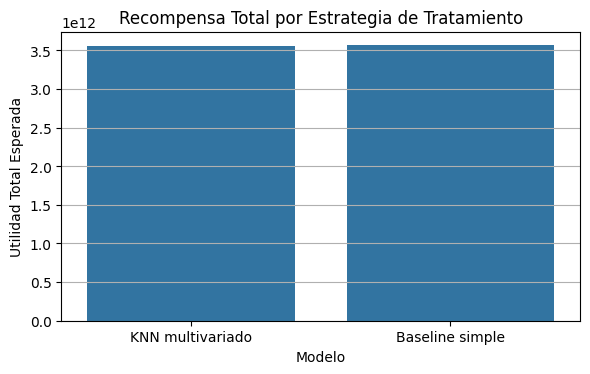

In [104]:
df_resultados_knn = evaluar_knn_baseline(df_info_clientes_rl, df_simulaciones_info)
graficar_recompensa_total(df_resultados_knn, comparar_con_baseline=True)


In [79]:
import pandas as pd
import matplotlib.pyplot as plt

def graficar_evolucion_ppo(monitor_csv_path: str, window: int = 100):
    """
    Grafica la evolución del reward por episodio y su media móvil
    a partir del archivo generado por Monitor(env, filename=...).
    
    :param monitor_csv_path: ruta al CSV de Monitor (salta la primera línea).
    :param window: tamaño de la ventana para la media móvil.
    """
    # 1) Leer el CSV (el primer renglón es metadata)
    df = pd.read_csv(monitor_csv_path, skiprows=1)
    # Asegúrate de que haya columna 'r' (reward) y opcionalmente 'l' (length).
    df = df.reset_index(drop=True)
    df['episode'] = df.index + 1

    # 2) Media móvil sobre reward
    df['reward_ma'] = df['r'].rolling(window=window, min_periods=1).mean()

    # 3) Graficar
    plt.figure(figsize=(10, 5))
    plt.plot(df['episode'], df['r'], alpha=0.3, label='Reward por episodio')
    plt.plot(df['episode'], df['reward_ma'], linewidth=2, label=f'MA-{window}')
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa")
    plt.title("Evolución del reward PPO (media móvil)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


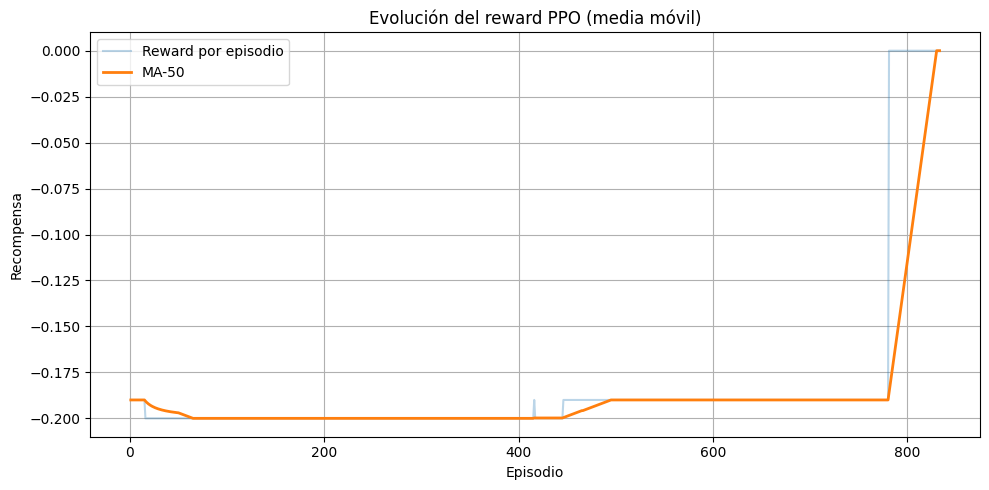

In [ ]:
graficar_evolucion_ppo("logs/ppo_eval_monitor.csv", window=50)
